In [1]:
# ---------------------------------------------------------------------
# Bloco 0 — Imports e configuracao global
# ---------------------------------------------------------------------
#
# Este bloco carrega todas as bibliotecas necessarias para o pipeline
# completo de classificacao binaria com XGBoost. As bibliotecas estao
# agrupadas por funcao:
#
# Manipulacao de dados:
#   - numpy: operacoes numericas em arrays (media, reshape, random, etc.)
#   - pandas: leitura, transformacao e analise de dados tabulares
#
# Visualizacao:
#   - matplotlib: graficos estaticos (curvas, barras, scatter)
#   - seaborn: camada de alto nivel sobre matplotlib para graficos
#     estatisticos com menos codigo
#
# Machine learning (sklearn):
#   - train_test_split: divide dados em treino/validacao/teste
#   - StratifiedKFold: validacao cruzada que preserva proporcao de classes
#   - OneHotEncoder: converte variaveis categoricas em colunas binarias
#   - StandardScaler: padroniza features para media 0 e desvio 1
#   - DummyClassifier: baseline que ignora features (chuta pela frequencia)
#   - LogisticRegression: modelo linear de classificacao
#   - Pipeline: encadeia transformacoes e modelo em um unico objeto
#   - metricas: roc_auc_score, precision, recall, f1, log_loss, etc.
#   - calibration_curve: calcula curva de calibracao (reliability diagram)
#   - IsotonicRegression: calibrador nao-parametrico (funcao monotonica)
#
# Modelo principal:
#   - xgboost: implementacao de gradient boosted trees otimizada
#
# Otimizacao de hiperparametros:
#   - optuna: busca bayesiana de hiperparametros via algoritmo TPE
#     (Tree-structured Parzen Estimator)
#
# Interpretabilidade:
#   - shap: calcula a contribuicao de cada feature para cada previsao
#     individual, baseado nos valores de Shapley da teoria dos jogos
#
# Serializacao:
#   - joblib: salva e carrega objetos Python em disco (modelos, etc.)

import warnings
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    log_loss, brier_score_loss,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

import xgboost as xgb
import optuna
import shap

# Silencia avisos de deprecacao futura e avisos internos do xgboost
# que nao afetam o resultado, apenas poluem a saida.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")

# Reduz a verbosidade do optuna para exibir apenas resultados finais
# em vez de cada trial individualmente.
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Seed global para reproducibilidade. Fixar este valor garante que
# todas as operacoes que dependem de aleatoriedade (split de dados,
# amostragem, inicializacao de modelos) produzam os mesmos resultados
# em execucoes repetidas, permitindo que terceiros repliquem os numeros.
SEED = 42
np.random.seed(SEED)

In [2]:
# ---------------------------------------------------------------------
# Bloco 1 — Geracao dos dados sinteticos
# ---------------------------------------------------------------------
#
# Este notebook resolve um problema de classificacao binaria: o target
# assume dois valores (0 ou 1). Exemplos reais incluem deteccao de
# fraude, previsao de churn, diagnostico medico e aprovacao de credito.
#
# Usamos dados sinteticos para que o notebook rode de forma autonoma,
# sem depender de arquivos externos. Em projetos reais, este bloco
# seria substituido pela leitura de dados (pd.read_csv, consulta a
# banco de dados, leitura de parquet, etc.).
#
# O dataset e configurado com desbalanceamento proposital: apenas ~8%
# das amostras pertencem a classe positiva (target=1), enquanto ~92%
# sao negativas (target=0). Essa proporcao simula cenarios reais onde
# a classe de interesse e rara. Um classificador trivial que sempre
# preve a classe majoritaria (0) teria ~92% de acuracia, mas utilidade
# pratica nula, pois nunca detectaria os casos positivos. Por isso,
# acuracia nao e uma metrica adequada para problemas desbalanceados.

# Parametros que controlam a estrutura do dataset sintetico
n_samples = 12_000        # numero total de observacoes
n_informative = 8         # features que carregam sinal preditivo real
n_redundant = 3           # combinacoes lineares exatas das informativas
n_noise = 4               # features de ruido puro, sem relacao com o target
minority_frac = 0.08      # proporcao da classe positiva no dataset

# Total de features numericas no dataset
n_features = n_informative + n_redundant + n_noise  # = 15

# make_classification gera um dataset com propriedades estatisticas
# controladas. Os parametros principais sao:
#   n_informative: quantas features tem correlacao real com o target
#   n_redundant: quantas sao combinacoes lineares das informativas
#   n_clusters_per_class: quantos agrupamentos cada classe forma no
#     espaco de features (mais clusters = fronteira mais complexa)
#   weights: proporcao de cada classe no dataset
#   flip_y: probabilidade de inverter aleatoriamente o target de cada
#     amostra, introduzindo ruido no rotulo (simula erros de anotacao)
X, y = make_classification(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=n_informative,
    n_redundant=n_redundant,
    n_clusters_per_class=2,
    weights=[1 - minority_frac, minority_frac],
    flip_y=0.03,
    random_state=SEED,
)

# Converte os arrays numpy em um DataFrame pandas para facilitar
# a manipulacao e a inspecao dos dados ao longo do notebook.
col_names = [f"feat_{i}" for i in range(n_features)]
df = pd.DataFrame(X, columns=col_names)
df["target"] = y

# --- Colunas categoricas simuladas ---
# Dados reais frequentemente contem variaveis de texto (regiao, canal
# de aquisicao, tipo de produto). Criamos essas colunas sinteticas
# para exercitar o tratamento de categoricas no pipeline.

rng = np.random.default_rng(SEED)

# Baixa cardinalidade: poucas categorias distintas. One-hot encoding
# e adequado nesse caso, pois gera poucas colunas adicionais.
df["cat_region"] = rng.choice(["norte", "sul", "leste", "oeste"], size=len(df))
df["cat_channel"] = rng.choice(["web", "app", "loja"], size=len(df))

# Alta cardinalidade: 300 identificadores distintos. Comum em dados
# reais (CEP, ID de loja, codigo de produto). One-hot encoding geraria
# 300 colunas esparsas, o que degrada performance e aumenta ruido.
# Este tipo de feature requer tratamento especial (target encoding,
# hashing, ou suporte nativo do XGBoost a categoricas). Neste notebook,
# optamos por descartar esta coluna para manter o foco no pipeline
# principal. Em producao, ela deveria receber tratamento adequado.
high_card_ids = [f"id_{i:04d}" for i in range(300)]
df["cat_high_card"] = rng.choice(high_card_ids, size=len(df))

# --- Valores ausentes (missing / NaN) ---
# Dados reais quase sempre possuem campos nao preenchidos (sensor que
# falhou, campo opcional em formulario, erro de integracao). Inserimos
# ~7% de missing em algumas colunas para simular essa realidade.
missing_cols = ["feat_0", "feat_2", "feat_5", "cat_region"]
for col in missing_cols:
    # Gera uma mascara booleana aleatoria: True para ~7% das linhas
    mask = rng.random(len(df)) < 0.07
    # Substitui os valores selecionados por NaN
    df.loc[mask, col] = np.nan

print(f"  Dataset criado: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"  Features numericas: {n_features}")
print(f"  Categoricas (baixa card.): cat_region, cat_channel")
print(f"  Categorica (alta card.): cat_high_card")
print(f"  Target: {df['target'].value_counts().to_dict()}")

  Dataset criado: 12000 linhas x 19 colunas
  Features numericas: 15
  Categoricas (baixa card.): cat_region, cat_channel
  Categorica (alta card.): cat_high_card
  Target: {0: 10870, 1: 1130}


In [3]:
# ---------------------------------------------------------------------
# Bloco 2 — Inspecao inicial dos dados
# ---------------------------------------------------------------------
#
# Antes de qualquer modelagem, e fundamental entender o que temos em
# maos. Esta etapa verifica:
#   - Dimensoes do dataset e tipos de dado de cada coluna
#   - Taxa de valores ausentes por coluna
#   - Distribuicao do target (proporcao de classes)
#   - Presenca de linhas duplicadas
#   - Colunas com variancia proxima de zero (sem poder discriminativo)
#   - Cardinalidade das variaveis categoricas (quantas categorias unicas)
#   - Faixas de valores das numericas via quantis robustos
#
# Em projetos com dados reais, esta etapa tambem deveria incluir:
# consistencia temporal, representatividade da amostra, mudancas de
# regime ao longo do tempo e verificacao de que todas as features
# estarao disponiveis no momento da inferencia em producao.

print("=" * 70)
print("Inspecao inicial dos dados")
print("=" * 70)

# Dimensoes basicas
print(f"\n  Shape: {df.shape[0]} linhas x {df.shape[1]} colunas")

# Contagem de colunas por tipo de dado (float64, int64, object, etc.)
print(f"\n  Tipos de coluna:")
print(df.dtypes.value_counts().to_string())

# Taxa de missing por coluna, mostrando apenas colunas afetadas.
# Colunas com mais de ~30% de missing merecem atencao especial: pode
# ser melhor descartar a coluna ou investigar a causa da ausencia.
missing_rate = df.isnull().mean().sort_values(ascending=False)
missing_nonzero = missing_rate[missing_rate > 0]
print(f"\n  Taxa de missing (colunas afetadas):")
if len(missing_nonzero) > 0:
    for col, rate in missing_nonzero.items():
        print(f"    {col:20s}: {rate:.1%}")
else:
    print("    Nenhuma coluna com missing.")

# Distribuicao do target. Em problemas desbalanceados, a classe
# minoritaria e a que queremos detectar, entao sua proporcao e
# um numero-chave para todas as decisoes subsequentes.
target_dist = df["target"].value_counts(normalize=True)
print(f"\n  Distribuicao do target:")
print(f"    Classe 0 (negativo): {target_dist.get(0, 0):.1%}")
print(f"    Classe 1 (positivo): {target_dist.get(1, 0):.1%}")

# Estatisticas descritivas das colunas numericas para identificar
# escalas discrepantes, valores extremos ou distribuicoes inesperadas.
print(f"\n  Estatisticas descritivas (numericas):")
desc = df.select_dtypes(include="number").describe().T[["mean", "std", "min", "max"]]
print(desc.to_string())

# Linhas duplicadas podem indicar problemas na coleta de dados.
# Em dados transacionais, duplicatas podem inflar artificialmente
# a representacao de certos padroes.
n_dup = df.duplicated().sum()
print(f"\n  Linhas duplicadas completas: {n_dup}")

# Colunas com variancia muito proxima de zero nao contribuem para
# a modelagem, pois todos os valores sao essencialmente iguais.
num_cols = df.select_dtypes(include="number").columns.drop("target", errors="ignore")
low_var = num_cols[df[num_cols].std() < 1e-6]
if len(low_var) > 0:
    print(f"\n  Colunas com variancia ~zero: {list(low_var)}")
else:
    print(f"\n  Nenhuma coluna numerica com variancia ~zero.")

# Cardinalidade das categoricas: quantas categorias distintas cada
# coluna possui, e quantas sao raras (aparecem em menos de 1% dos
# dados). Categorias raras podem causar instabilidade no modelo.
cat_cols_all = df.select_dtypes(include=["object"]).columns.tolist()

if len(cat_cols_all) > 0:
    print(f"\n  Cardinalidade das categoricas:")
    for col in cat_cols_all:
        vc_abs = df[col].value_counts(dropna=False)
        vc_rel = df[col].value_counts(dropna=False, normalize=True)
        n_unique = df[col].nunique(dropna=False)
        n_rare = int((vc_rel < 0.01).sum())

        print(f"    {col:20s}: {n_unique:3d} categorias | {n_rare:3d} raras (<1%)")

        # Mostra as 5 categorias menos frequentes para inspecao
        tail_info = pd.DataFrame({
            "count": vc_abs,
            "rate": vc_rel
        }).sort_values(["count", "rate"], ascending=[True, True]).head(5)

        print(tail_info.to_string())
        print()
else:
    print("\n  Nenhuma coluna categorica detectada.")

# Faixas robustas (percentis 1% e 99%) para identificar valores
# extremos sem ser sensivel a outliers individuais.
print(f"\n  Faixas robustas (1% / 99%) para numericas:")
num_cols_all = df.select_dtypes(include="number").columns.drop("target", errors="ignore")

if len(num_cols_all) > 0:
    q = df[num_cols_all].quantile([0.01, 0.50, 0.99]).T
    q.columns = ["q01", "mediana", "q99"]
    print(q.to_string())

Inspecao inicial dos dados

  Shape: 12000 linhas x 19 colunas

  Tipos de coluna:
float64    15
object      3
int32       1

  Taxa de missing (colunas afetadas):
    feat_0              : 7.1%
    feat_5              : 6.9%
    feat_2              : 6.9%
    cat_region          : 6.8%

  Distribuicao do target:
    Classe 0 (negativo): 90.6%
    Classe 1 (positivo): 9.4%

  Estatisticas descritivas (numericas):
             mean       std        min        max
feat_0  -0.012853  1.879545  -7.568248   6.244021
feat_1   0.005106  0.994898  -3.616564   3.695194
feat_2   0.921362  1.783231  -6.827678   7.531705
feat_3  -0.001304  1.007289  -3.624920   4.077853
feat_4  -1.008940  1.894688  -8.100635   6.122047
feat_5   0.979887  1.814779  -6.217038   7.577733
feat_6  -1.459399  3.565274 -14.410843  12.520230
feat_7   0.006688  2.003345  -6.256176   8.277190
feat_8  -0.074015  2.266061  -7.668999   9.550005
feat_9  -0.115701  1.910993  -6.820810   7.140173
feat_10 -0.009461  1.009336  -3.8

In [4]:
# ---------------------------------------------------------------------
# Bloco 3 — Analise exploratoria (EDA)
# ---------------------------------------------------------------------
#
# A analise exploratoria investiga os dados antes de construir qualquer
# modelo. O objetivo e entender a estrutura do problema, detectar
# anomalias e identificar armadilhas que possam prejudicar a modelagem.
#
# Cobrimos quatro aspectos:
#   1. Razao de desbalanceamento entre classes
#   2. Distribuicao das variaveis categoricas
#   3. Correlacoes entre features numericas
#   4. Relacao entre features e o target
#
# Em projetos reais, a EDA seria mais extensa: analise temporal,
# deteccao de outliers, correlacao com o target por segmento, etc.

print("=" * 70)
print("Analise exploratoria (EDA)")
print("=" * 70)

# --- 1. Razao de desbalanceamento ---
# A razao indica quantos exemplos da classe majoritaria existem para
# cada exemplo da classe minoritaria. Uma razao de 11:1 significa que
# um classificador trivial (que sempre preve a classe majoritaria)
# teria ~92% de acuracia. Por isso, metricas como PR-AUC e F1 sao
# mais informativas neste tipo de problema.
vc = df["target"].value_counts()
imbalance_ratio = vc.max() / vc.min()
print(f"\n  Imbalance ratio: {imbalance_ratio:.1f}:1")
print(f"    (Para cada positivo, ha ~{imbalance_ratio:.0f} negativos)")

# --- 2. Distribuicao das categoricas ---
cat_cols = ["cat_region", "cat_channel"]
for col in cat_cols:
    print(f"\n  Distribuicao de '{col}':")
    print(df[col].value_counts(dropna=False).to_string())

# --- 3. Matriz de correlacao ---
# O coeficiente de correlacao de Pearson mede a associacao linear
# entre duas variaveis, variando de -1 (anticorrelacao perfeita) a
# +1 (correlacao perfeita). Pares com |r| > 0.7 sao quase redundantes.
#
# Em modelos baseados em arvores (como XGBoost), features
# correlacionadas nao causam problemas numericos como em modelos
# lineares, mas dividem a importancia entre si, o que dificulta
# a interpretacao das contribuicoes individuais.
num_cols_for_corr = df.select_dtypes(include="number").columns.drop("target", errors="ignore")
corr_matrix = df[num_cols_for_corr].corr()

print("\n  Pares com correlacao > 0.7:")
high_corr_found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"    {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {r:.3f}")
            high_corr_found = True
if not high_corr_found:
    print("    Nenhum par detectado.")

# --- 4a. Relacao target vs categoricas ---
# Verifica se a taxa de positivos varia entre os grupos categoricos.
# Se variar, a variavel carrega informacao sobre o target.
print("\n" + "=" * 70)
print("Relacao com target por categorias")
print("=" * 70)

for col in ["cat_region", "cat_channel"]:
    if col in df.columns:
        grp = (
            df.groupby(col, dropna=False)["target"]
            .agg(["mean", "count"])
            .rename(columns={"mean": "taxa_target", "count": "n"})
            .sort_values("taxa_target", ascending=False)
        )
        print(f"\n  Target por {col}:")
        print(grp.to_string())

# --- 4b. Relacao target vs quantis das numericas ---
# Divide cada feature numerica em 5 faixas de igual frequencia e
# calcula a taxa de positivos em cada faixa. Se a taxa varia
# monotonicamente, a feature tem poder discriminativo.
print("\n" + "=" * 70)
print("Relacao com target por quantis das numericas")
print("=" * 70)

num_probe_cols = [c for c in ["feat_0", "feat_1", "feat_2", "feat_3", "feat_5"] if c in df.columns]

for col in num_probe_cols:
    aux = df[[col, "target"]].copy()
    # qcut divide em faixas com quantidade aproximadamente igual de amostras
    aux["faixa"] = pd.qcut(aux[col], q=5, duplicates="drop")
    grp = (
        aux.groupby("faixa", observed=True)["target"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "taxa_target", "count": "n"})
    )
    print(f"\n  Target por quantis de {col}:")
    print(grp.to_string())

Analise exploratoria (EDA)

  Imbalance ratio: 9.6:1
    (Para cada positivo, ha ~10 negativos)

  Distribuicao de 'cat_region':
cat_region
leste    2816
norte    2814
sul      2796
oeste    2756
NaN       818

  Distribuicao de 'cat_channel':
cat_channel
loja    4013
web     3994
app     3993

  Pares com correlacao > 0.7:
    feat_4 <-> feat_12: -0.713
    feat_6 <-> feat_7: 0.714

Relacao com target por categorias

  Target por cat_region:
            taxa_target     n
cat_region                   
NaN            0.099022   818
leste          0.098722  2816
oeste          0.093251  2756
sul            0.092990  2796
norte          0.090263  2814

  Target por cat_channel:
             taxa_target     n
cat_channel                   
web             0.097897  3994
app             0.095417  3993
loja            0.089210  4013

Relacao com target por quantis das numericas

  Target por quantis de feat_0:
                  taxa_target     n
faixa                              
(-7.569, -

In [5]:
# ---------------------------------------------------------------------
# Bloco 4 — Split estratificado: treino / validacao / teste
# ---------------------------------------------------------------------
#
# Data leakage ocorre quando informacoes que nao estariam disponiveis
# em producao influenciam o processo de treinamento. O resultado sao
# metricas infladas durante o desenvolvimento e performance degradada
# quando o modelo e implantado.
#
# Para evitar leakage, dividimos os dados em tres particoes disjuntas:
#   - Treino (~70%): dados usados para ajustar os parametros do modelo.
#   - Validacao (~15%): dados usados para ajustar hiperparametros e
#     decidir quando parar o treinamento (early stopping).
#   - Teste (~15%): dados tocados uma unica vez, na avaliacao final.
#     Serve como estimativa da performance em dados nunca vistos.
#
# O split e estratificado, o que significa que a proporcao de classes
# (target=0 vs target=1) e preservada em cada particao. Em dados
# desbalanceados, um split puramente aleatorio poderia gerar particoes
# com proporcoes muito diferentes da populacao original.
#
# Alternativas para cenarios de producao:
#   - Out-of-time validation: usar os dados mais recentes como teste,
#     simulando o uso temporal do modelo.
#   - GroupKFold: garantir que a mesma entidade (cliente, loja, etc.)
#     fique inteira em uma unica particao, evitando leakage por
#     entidade.

print("=" * 70)
print("Split estratificado: treino / validacao / teste")
print("=" * 70)

val_size = 0.15
test_size = 0.15

# Primeiro split: separa o teste do restante.
# stratify=df["target"] garante proporcoes iguais de classes.
df_temp, df_test = train_test_split(
    df,
    test_size=test_size,
    stratify=df["target"],
    random_state=SEED,
)

# Segundo split: do restante, separa treino e validacao.
# O tamanho relativo da validacao precisa ser recalculado, pois
# agora operamos sobre (1 - test_size) dos dados originais.
relative_val = val_size / (1 - test_size)
df_train, df_val = train_test_split(
    df_temp,
    test_size=relative_val,
    stratify=df_temp["target"],
    random_state=SEED,
)

# Reseta os indices de cada particao para que sejam contiguos
# (0, 1, 2, ...). Isso evita problemas de alinhamento quando usamos
# indexacao posicional (iloc) mais adiante, especialmente na validacao
# cruzada e no calculo de predicoes out-of-fold.
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print()
for name, part in [("Treino", df_train), ("Validacao", df_val), ("Teste", df_test)]:
    n = len(part)
    pct = n / len(df) * 100
    pos_rate = part["target"].mean()
    print(f"  {name:10s}: {n:>6d} linhas ({pct:.0f}%) | target=1: {pos_rate:.3f}")

print(f"\n  Proporcao do target preservada em todas as particoes.")
print(f"  O conjunto de teste nao sera tocado ate a avaliacao final.")

Split estratificado: treino / validacao / teste

  Treino    :   8399 linhas (70%) | target=1: 0.094
  Validacao :   1801 linhas (15%) | target=1: 0.094
  Teste     :   1800 linhas (15%) | target=1: 0.094

  Proporcao do target preservada em todas as particoes.
  O conjunto de teste nao sera tocado ate a avaliacao final.


In [6]:
# ---------------------------------------------------------------------
# Bloco 5 — Preprocessamento unificado (sem leakage)
# ---------------------------------------------------------------------
#
# Este bloco define um pipeline unico de preprocessamento encapsulado
# em funcoes reutilizaveis. O mesmo pipeline e usado em todas as
# etapas: validacao cruzada, tunagem de hiperparametros, treinamento
# final e inferencia. Isso garante consistencia entre todas as etapas
# e elimina divergencias que poderiam invalidar comparacoes.
#
# O pipeline executa, nesta ordem:
#   1. Criacao de flags de ausencia (binarias)
#   2. Imputacao de valores ausentes (mediana para numericas, moda
#      para categoricas), usando sempre estatisticas do treino
#   3. Feature engineering (interacoes e razoes entre features)
#   4. One-hot encoding das categoricas de baixa cardinalidade
#   5. Descarte da coluna de alta cardinalidade (cat_high_card)
#
# Regra fundamental contra leakage: toda estatistica usada na
# transformacao (mediana, moda, categorias do one-hot) e calculada
# exclusivamente no conjunto de treino do momento. O conjunto de
# validacao e teste sao transformados com essas mesmas estatisticas,
# sem recalcula-las.

print("=" * 70)
print("Preprocessamento unificado (sem leakage)")
print("=" * 70)

# --- Definicoes globais de colunas ---
# Estas listas definem quais colunas recebem cada tipo de tratamento.
# Sao usadas por todas as funcoes do pipeline.

# Categoricas de baixa cardinalidade: receberao one-hot encoding.
low_card_cats = ["cat_region", "cat_channel"]

# Categorica de alta cardinalidade: sera descartada neste pipeline.
# Em producao, alternativas como target encoding (out-of-fold) ou
# o suporte nativo do XGBoost a categoricas seriam preferidos.
high_card_cat = "cat_high_card"

# Colunas que contem valores ausentes no dataset original.
cols_with_missing = ["feat_0", "feat_2", "feat_5", "cat_region"]

# Identifica todas as colunas numericas originais do dataset,
# excluindo o target, as categoricas e a coluna de alta cardinalidade.
all_non_feature = ["target", high_card_cat] + low_card_cats
raw_num_cols = [
    c for c in df_train.columns
    if c not in all_non_feature
    and pd.api.types.is_numeric_dtype(df_train[c])
]


def add_missing_flags(df_in: pd.DataFrame) -> pd.DataFrame:
    '''Cria colunas binarias indicando se o valor original era ausente.

    Para cada coluna listada em cols_with_missing, cria uma nova coluna
    com sufixo '_is_missing' contendo 1 onde o valor era NaN e 0 caso
    contrario. O fato de um campo estar ausente pode ser informativo
    por si so (por exemplo, um cliente que nao informa a renda pode ter
    perfil de risco diferente de um que informa).

    Este passo e executado antes da imputacao, para preservar a
    informacao de quais valores eram originalmente ausentes.
    '''
    df_out = df_in.copy()
    for col in cols_with_missing:
        if col in df_out.columns:
            df_out[f"{col}_is_missing"] = df_out[col].isna().astype(np.int8)
    return df_out


def add_feature_engineering(df_in: pd.DataFrame) -> pd.DataFrame:
    '''Cria features derivadas a partir das features originais.

    Features derivadas combinam informacoes de duas ou mais features
    existentes e podem capturar relacoes nao-lineares que o modelo
    teria dificuldade de aprender sozinho.

    Features criadas:
      - feat_0_x_feat_1: produto (interacao) entre feat_0 e feat_1.
        Captura efeitos conjuntos: o impacto de feat_0 pode depender
        do valor de feat_1.
      - feat_2_over_feat_3: razao entre feat_2 e feat_3, com protecao
        contra divisao por zero (denominador limitado a minimo de 1e-3)
        e clipping do resultado no intervalo [-20, 20] para evitar
        valores extremos que degradam o treinamento.
      - n_missing_total: quantidade total de campos ausentes por
        observacao. Amostras com muitos campos ausentes podem ter
        perfil sistematicamente diferente.
    '''
    df_out = df_in.copy()

    # Interacao multiplicativa entre feat_0 e feat_1
    df_out["feat_0_x_feat_1"] = df_out["feat_0"] * df_out["feat_1"]

    # Razao com protecao dupla:
    #   1. clip(lower=1e-3) no denominador evita divisao por zero
    #   2. clip(-20, 20) no resultado evita valores extremos
    denom = df_out["feat_3"].abs().clip(lower=1e-3)
    df_out["feat_2_over_feat_3"] = (df_out["feat_2"] / denom).clip(-20, 20)

    # Contagem de campos ausentes por observacao, somando as flags
    # binarias criadas no passo anterior
    missing_flag_cols = [c for c in df_out.columns if c.endswith("_is_missing")]
    df_out["n_missing_total"] = df_out[missing_flag_cols].sum(axis=1)

    return df_out


def fit_preprocessor(df_fit: pd.DataFrame) -> dict:
    '''Calcula todas as estatisticas do preprocessamento a partir do treino.

    Recebe o DataFrame de treino (pode ser o treino global ou o treino
    de um fold da validacao cruzada) e retorna um dicionario contendo:
      - train_medians: mediana de cada coluna numerica (para imputacao)
      - train_modes: moda de cada coluna categorica (para imputacao)
      - ohe: objeto OneHotEncoder ajustado (para encoding)
      - ohe_feature_names: nomes das colunas geradas pelo one-hot
      - feature_order: lista final ordenada de todas as features

    O one-hot encoder usa drop='first' para evitar multicolinearidade
    perfeita: uma variavel com K categorias gera K-1 colunas binarias,
    pois a K-esima e implicitamente determinada pelas demais. Isso
    melhora a estabilidade da importancia das features e dos valores
    SHAP, especialmente para modelos baseados em arvores.
    '''
    # Passo 1: criar flags de ausencia antes de imputar
    df_fit = add_missing_flags(df_fit)

    # Passo 2: calcular estatisticas para imputacao
    train_medians = df_fit[raw_num_cols].median()

    train_modes = {}
    for col in low_card_cats:
        mode_values = df_fit[col].mode(dropna=True)
        train_modes[col] = mode_values.iloc[0] if len(mode_values) > 0 else "desconhecido"

    # Passo 3: imputar para que o feature engineering opere sobre
    # valores completos (sem NaN)
    df_fit = df_fit.copy()
    for col in raw_num_cols:
        df_fit[col] = df_fit[col].fillna(train_medians[col])
    for col in low_card_cats:
        df_fit[col] = df_fit[col].fillna(train_modes[col])

    # Passo 4: criar features derivadas
    df_fit = add_feature_engineering(df_fit)

    # Passo 5: ajustar o one-hot encoder no treino
    ohe = OneHotEncoder(
        drop='first',           # evita multicolinearidade perfeita
        sparse_output=False,    # retorna array denso (mais facil de manipular)
        handle_unknown="ignore",# categorias desconhecidas viram zeros
    )
    ohe.fit(df_fit[low_card_cats])

    ohe_feature_names = list(ohe.get_feature_names_out(low_card_cats))

    # Monta a lista final de features na ordem correta.
    # Inclui: numericas originais + flags de missing + features derivadas
    # + colunas do one-hot encoding. Exclui: target, categoricas brutas
    # e a coluna de alta cardinalidade.
    base_feature_cols = [
        c for c in df_fit.columns
        if c not in (["target", high_card_cat] + low_card_cats)
    ]
    feature_order = base_feature_cols + ohe_feature_names

    return {
        "train_medians": train_medians,
        "train_modes": train_modes,
        "ohe": ohe,
        "ohe_feature_names": ohe_feature_names,
        "feature_order": feature_order,
    }


def transform_with_preprocessor(
    df_in: pd.DataFrame,
    preprocessor: dict,
    return_target: bool = True,
):
    '''Aplica o preprocessamento a um DataFrame qualquer.

    Usa as estatisticas armazenadas no dicionario preprocessor (que
    foi ajustado apenas no treino) para transformar qualquer conjunto
    de dados (treino, validacao, teste ou dados novos em producao).

    Retorna:
      - X: DataFrame com as features finais, na ordem definida por
        feature_order, com indice resetado.
      - y: Series com o target (se return_target=True e a coluna
        existir), ou None.
    '''
    # Aplica os mesmos passos na mesma ordem
    df_t = add_missing_flags(df_in)

    # Imputacao com as estatisticas do treino (nao recalcula)
    for col in raw_num_cols:
        df_t[col] = df_t[col].fillna(preprocessor["train_medians"][col])
    for col in low_card_cats:
        df_t[col] = df_t[col].fillna(preprocessor["train_modes"][col])

    # Feature engineering (opera sobre dados ja imputados)
    df_t = add_feature_engineering(df_t)

    # One-hot encoding usando o encoder ajustado no treino.
    # Categorias nao vistas no treino serao codificadas como zeros
    # (handle_unknown="ignore").
    encoded = pd.DataFrame(
        preprocessor["ohe"].transform(df_t[low_card_cats]),
        columns=preprocessor["ohe_feature_names"],
        index=df_t.index,
    )

    # Concatena features base (numericas + derivadas + flags) com
    # as colunas do one-hot encoding
    base = df_t.drop(columns=["target", high_card_cat] + low_card_cats, errors="ignore")
    X = pd.concat([base, encoded], axis=1)

    # Reordena e preenche colunas eventualmente ausentes com zero.
    # Isso garante que o schema de features seja identico em todos
    # os contextos (treino, validacao, teste, cada fold do CV).
    X = X.reindex(columns=preprocessor["feature_order"], fill_value=0.0)
    X = X.reset_index(drop=True)
    
    # verificar se alguma coluna ficou somente zero
    assert X.shape[1] == len(preprocessor["feature_order"]), \
        f"Schema inválido: esperado {len(preprocessor['feature_order'])} features"
    
    y = None
    if return_target and "target" in df_in.columns:
        y = df_in["target"].reset_index(drop=True)

    return X, y


# --- Ajuste do preprocessador no treino global ---
# Este preprocessador sera usado para o treinamento final e para a
# avaliacao no teste. A validacao cruzada e o Optuna ajustam um
# preprocessador separado em cada fold para evitar leakage intra-fold.
preprocessor = fit_preprocessor(df_train)

# Extrai componentes para acesso direto quando conveniente
feature_cols = preprocessor["feature_order"]

# Transforma os tres conjuntos com o preprocessador do treino global
X_train, y_train = transform_with_preprocessor(df_train, preprocessor, return_target=True)
X_val, y_val = transform_with_preprocessor(df_val, preprocessor, return_target=True)
X_test, y_test = transform_with_preprocessor(df_test, preprocessor, return_target=True)

# Preserva os valores categoricos crus (antes do encoding) para a
# analise por subgrupo posterior (Bloco 10). Esses valores nao sao
# usados como features do modelo.
val_meta = df_val[low_card_cats].reset_index(drop=True).copy()
test_meta = df_test[low_card_cats].reset_index(drop=True).copy()

print(f"  Medianas do treino: {len(preprocessor['train_medians'])} colunas numericas")
print(f"  Modas do treino: {preprocessor['train_modes']}")
print(f"  One-hot criou {len(preprocessor['ohe_feature_names'])} colunas (com drop='first')")
print(f"  Features finais: {len(feature_cols)}")
print(f"  X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")
print(f"\n  Nota sobre missing: optamos por imputar manualmente e criar flags")
print(f"  de ausencia, em vez de usar o tratamento nativo de NaN do XGBoost.")
print(f"  O XGBoost aprende automaticamente a melhor direcao para NaNs em")
print(f"  cada split de cada arvore, o que pode ser mais eficaz. Em projetos")
print(f"  reais, vale comparar ambas as abordagens. A imputacao manual foi")
print(f"  escolhida aqui por ser mais explicita e educativa.")

Preprocessamento unificado (sem leakage)
  Medianas do treino: 15 colunas numericas
  Modas do treino: {'cat_region': 'sul', 'cat_channel': 'app'}
  One-hot criou 5 colunas (com drop='first')
  Features finais: 27
  X_train: (8399, 27) | X_val: (1801, 27) | X_test: (1800, 27)

  Nota sobre missing: optamos por imputar manualmente e criar flags
  de ausencia, em vez de usar o tratamento nativo de NaN do XGBoost.
  O XGBoost aprende automaticamente a melhor direcao para NaNs em
  cada split de cada arvore, o que pode ser mais eficaz. Em projetos
  reais, vale comparar ambas as abordagens. A imputacao manual foi
  escolhida aqui por ser mais explicita e educativa.


In [7]:
pd.set_option('display.max_columns', None)
X_train.head(30)

,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11,feat_12,feat_13,feat_14,feat_0_is_missing,feat_2_is_missing,feat_5_is_missing,cat_region_is_missing,feat_0_x_feat_1,feat_2_over_feat_3,n_missing_total,cat_region_norte,cat_region_oeste,cat_region_sul,cat_channel_loja,cat_channel_web
0,0.435882,-1.738175,-0.135126,0.605900,-1.549537,0.420833,0.686278,0.341739,-1.698011,-2.708787,-0.415126,-0.659572,-0.855691,-0.436938,-3.307429,0,0,0,0,-0.757638,-0.223017,0,0.0,1.0,0.0,1.0,0.0
1,0.406294,0.364057,2.993028,0.469746,-1.226457,2.434382,-6.438509,-3.023588,-0.100763,1.230790,0.967610,0.780194,1.117120,-0.785672,-0.739374,0,0,0,0,0.147914,6.371586,0,0.0,1.0,0.0,1.0,0.0
2,1.322600,-0.224635,0.823303,1.951127,0.653330,1.042656,-0.058708,-0.509909,-3.412287,0.720453,-0.622104,0.420650,-0.917132,1.218660,-2.022136,0,0,0,0,-0.297102,0.421963,0,0.0,0.0,1.0,1.0,0.0
3,1.002453,2.355695,1.679866,-0.611831,-1.979489,1.009896,-1.602395,-1.180468,-2.822477,0.713779,0.294695,-1.578171,1.499771,0.294336,-1.809425,0,0,1,0,2.361474,2.745636,1,1.0,0.0,0.0,0.0,0.0
4,1.428280,0.036548,-0.177079,-0.883181,-0.910930,-0.303363,-4.033550,-0.458083,-0.310050,2.338639,-0.877390,2.827279,1.285406,-0.371378,-1.364734,0,0,0,0,0.052201,-0.200502,0,0.0,1.0,0.0,0.0,1.0
5,3.715547,-0.532201,-1.872069,-1.141910,-1.769999,1.009896,2.453435,2.550595,-4.616182,1.185643,0.676477,1.083607,0.433989,-1.041789,-5.239000,0,0,1,0,-1.977419,-1.639419,1,0.0,0.0,1.0,0.0,1.0
6,3.284308,-0.182398,-2.950003,1.594301,-0.534442,-1.181166,3.283605,4.656488,2.064850,-1.943811,1.943392,-0.755688,-4.749951,1.541009,0.355517,0,0,0,0,-0.599052,-1.850343,0,0.0,0.0,1.0,0.0,1.0
7,0.708131,1.445714,2.255908,-0.698255,0.702357,1.032913,-4.045567,-2.488951,-1.263464,2.579750,-0.366712,1.629184,0.840442,-2.669936,-0.487069,0,0,0,0,1.023755,3.230779,0,1.0,0.0,0.0,0.0,0.0
8,0.819449,-0.035498,2.912682,-0.583235,-2.632651,2.115941,-2.685663,1.831226,-0.656788,-1.731183,-0.572315,1.386761,-0.847225,0.061854,-4.674433,0,0,0,0,-0.029089,4.994009,0,0.0,0.0,0.0,0.0,1.0
9,-1.891210,-1.493904,0.825794,0.951626,-1.306490,0.214403,2.677818,2.039441,2.649113,-0.845160,0.197990,-2.644959,1.562995,-0.235816,2.166271,0,0,0,0,2.825287,0.867772,0,1.0,0.0,0.0,0.0,1.0


In [8]:
y_train.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int32

In [9]:
# ---------------------------------------------------------------------
# Bloco 6 — Baselines
# ---------------------------------------------------------------------
#
# Baselines sao modelos simples que servem como referencia minima de
# performance. Se o modelo sofisticado (XGBoost) nao conseguir supera-
# los, a complexidade adicional nao se justifica. Alem disso, ganhos
# excessivamente grandes em relacao ao baseline (por exemplo, AUC
# saltando de 0.50 para 0.99) podem ser sinal de data leakage.
#
# Usamos dois baselines:
#
#   DummyClassifier (strategy="stratified"): gera previsoes aleatorias
#   respeitando a proporcao de classes do treino. Nao usa nenhuma
#   feature. Qualquer modelo util precisa superar este piso.
#
#   LogisticRegression: modelo linear classico, rapido e interpretavel.
#   Usa class_weight="balanced" para atribuir peso maior a classe
#   minoritaria durante o treinamento, compensando o desbalanceamento.
#   O StandardScaler dentro do Pipeline padroniza as features para
#   media 0 e desvio 1 antes do modelo linear, o que e necessario
#   porque os coeficientes da regressao logistica dependem da escala
#   das features. Para o XGBoost, isso nao e necessario: arvores de
#   decisao particionam por limiares ("feat_0 > 2.5?"), e apenas a
#   ordem relativa dos valores importa, nao a escala absoluta.

print("=" * 70)
print("Baselines: Dummy + Regressao logistica")
print("=" * 70)

# Baseline 1: DummyClassifier
dummy = DummyClassifier(strategy="stratified", random_state=SEED)
dummy.fit(X_train, y_train)

# Baseline 2: Logistic Regression com scaling
lr_pipe = SkPipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
])
lr_pipe.fit(X_train, y_train)

# Metricas na validacao (referencia durante o desenvolvimento)
print(f"\n  Metricas na validacao:")
for name, model in [("Dummy", dummy), ("LogisticReg", lr_pipe)]:
    proba = model.predict_proba(X_val)[:, 1]
    pred = model.predict(X_val)
    print(f"  {name:15s}: ROC-AUC={roc_auc_score(y_val, proba):.4f} | "
          f"PR-AUC={average_precision_score(y_val, proba):.4f} | "
          f"F1={f1_score(y_val, pred):.4f}")

# Metricas no teste, calculadas agora para comparacao justa com o
# XGBoost no Bloco 9. Todos os modelos sao avaliados no mesmo
# conjunto de teste para que a comparacao seja valida.
print(f"\n  Metricas no teste (para comparacao com XGBoost):")
baseline_results_test = {}
for name, model in [("Dummy", dummy), ("LogisticReg", lr_pipe)]:
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    metrics = {
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
        "F1": f1_score(y_test, pred),
    }
    baseline_results_test[name] = metrics
    print(f"  {name:15s}: ROC-AUC={metrics['ROC-AUC']:.4f} | "
          f"PR-AUC={metrics['PR-AUC']:.4f} | "
          f"F1={metrics['F1']:.4f}")

print(f"\n  O XGBoost precisa superar estes valores no teste para se justificar.")

Baselines: Dummy + Regressao logistica

  Metricas na validacao:
  Dummy          : ROC-AUC=0.5090 | PR-AUC=0.0962 | F1=0.1111
  LogisticReg    : ROC-AUC=0.7653 | PR-AUC=0.2937 | F1=0.3042

  Metricas no teste (para comparacao com XGBoost):
  Dummy          : ROC-AUC=0.5227 | PR-AUC=0.0994 | F1=0.1353
  LogisticReg    : ROC-AUC=0.7791 | PR-AUC=0.2757 | F1=0.3218

  O XGBoost precisa superar estes valores no teste para se justificar.


In [10]:
# ---------------------------------------------------------------------
# Bloco 7 — Validacao cruzada estratificada
# ---------------------------------------------------------------------
#
# Avaliar o modelo em um unico conjunto de validacao pode gerar uma
# estimativa enviesada: aquele split particular pode ser atipicamente
# facil ou dificil. A validacao cruzada (CV) resolve isso dividindo
# o treino em K folds e treinando K vezes. Em cada iteracao, um fold
# diferente serve como validacao enquanto os demais servem como treino.
# O resultado e uma distribuicao de metricas (media +/- desvio padrao),
# o que da uma estimativa mais confiavel da performance.
#
# StratifiedKFold garante que cada fold mantenha a proporcao de classes
# do dataset original. Sem estratificacao, um fold poderia conter
# poucos positivos (ou nenhum), gerando metricas instáveis.
#
# Para evitar leakage intra-fold, o preprocessamento (imputacao, OHE)
# e reajustado em cada fold usando apenas os dados de treino daquele
# fold. Se calculassemos as medianas no treino inteiro e aplicassemos
# dentro do CV, informacoes da validacao do fold vazariam para o treino.
#
# Se as metricas variam muito entre folds (por exemplo, AUC de 0.90
# em um fold e 0.70 em outro), isso indica fragilidade do modelo:
# a performance e sensivel a quais dados estao no treino.

print("=" * 70)
print("Validacao cruzada estratificada (5 folds)")
print("=" * 70)

N_FOLDS = 5

# Hiperparametros base usados na validacao cruzada, antes da tunagem.
# Sao valores razoaveis de partida, nao otimizados.
base_cv_params = {
    "objective": "binary:logistic",  # funcao de perda para classificacao binaria
    "eval_metric": "aucpr",          # metrica monitorada no early stopping
    "tree_method": "hist",           # algoritmo de construcao de arvore (rapido)
    "max_depth": 5,                  # profundidade maxima de cada arvore
    "learning_rate": 0.1,            # fator de encolhimento por iteracao
    "subsample": 0.8,               # fracao de linhas amostradas por arvore
    "colsample_bytree": 0.8,        # fracao de colunas amostradas por arvore
    "min_child_weight": 5,          # peso minimo em um no-folha
    "reg_alpha": 0.1,               # regularizacao L1 nos pesos das folhas
    "reg_lambda": 1.0,              # regularizacao L2 nos pesos das folhas
    "gamma": 0.1,                   # ganho minimo para aceitar um split
    "verbosity": 0,                 # sem logs internos do xgboost
    "seed": SEED,
}
cv_num_boost_round = 300  # numero maximo de arvores por treinamento


def fit_booster(Xtr, ytr, Xva, yva, params, num_boost_round=300, early_stopping_rounds=30):
    '''Treina um booster XGBoost com early stopping.

    Converte os DataFrames em DMatrix (formato nativo do XGBoost,
    mais eficiente em memoria e velocidade), treina o modelo e
    retorna o booster treinado junto com as probabilidades previstas
    na validacao.

    O early stopping interrompe o treinamento quando a metrica de
    validacao nao melhora por early_stopping_rounds consecutivos.
    Isso evita que o modelo memorize o treino (overfitting).
    '''
    dtrain = xgb.DMatrix(Xtr, label=ytr, feature_names=Xtr.columns.tolist())
    dval = xgb.DMatrix(Xva, label=yva, feature_names=Xva.columns.tolist())

    booster = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=[(dval, "val")],
        early_stopping_rounds=early_stopping_rounds,
        verbose_eval=False,
    )

    # best_iteration contem o indice (0-based) da melhor iteracao.
    # Somamos 1 porque iteration_range espera o limite superior exclusivo.
    best_iter = booster.best_iteration + 1 if booster.best_iteration is not None else num_boost_round
    proba_val = booster.predict(dval, iteration_range=(0, best_iter))
    return booster, proba_val


# Configura o gerador de folds estratificados
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Estruturas para armazenar resultados de cada fold
cv_metrics = {"ROC-AUC": [], "PR-AUC": [], "F1@0.50": [], "Log Loss": []}
cv_importances = []

# Array para armazenar predicoes out-of-fold (OOF): cada observacao
# do treino recebe uma previsao feita pelo modelo que nao a viu.
oof_cv_pred = np.zeros(len(df_train), dtype=float)

for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(df_train, df_train["target"]), 1):
    # Separa os dados do fold atual
    df_tr_fold = df_train.iloc[tr_idx].copy()
    df_va_fold = df_train.iloc[va_idx].copy()

    # Ajusta um preprocessador independente para este fold, usando
    # apenas os dados de treino do fold. Isso evita leakage intra-fold.
    pp_fold = fit_preprocessor(df_tr_fold)

    # Transforma treino e validacao do fold
    Xtr_fold, ytr_fold = transform_with_preprocessor(df_tr_fold, pp_fold, return_target=True)
    Xva_fold, yva_fold = transform_with_preprocessor(df_va_fold, pp_fold, return_target=True)

    # Calcula scale_pos_weight para compensar o desbalanceamento.
    # Este parametro faz com que erros na classe minoritaria pesem
    # mais durante o treinamento. O valor e a razao entre negativos
    # e positivos no treino do fold.
    pos_fold = int(ytr_fold.sum())
    neg_fold = len(ytr_fold) - pos_fold

    fold_params = {
        **base_cv_params,
        "scale_pos_weight": neg_fold / max(pos_fold, 1),
    }

    # Treina o modelo do fold com early stopping
    fold_model, fold_proba = fit_booster(
        Xtr_fold, ytr_fold, Xva_fold, yva_fold,
        params=fold_params,
        num_boost_round=cv_num_boost_round,
        early_stopping_rounds=30,
    )

    # Converte probabilidades em previsoes binarias com threshold 0.5
    fold_pred = (fold_proba >= 0.5).astype(int)

    # Armazena as predicoes out-of-fold para avaliacao global
    oof_cv_pred[va_idx] = fold_proba

    # Calcula e armazena as metricas do fold
    cv_metrics["ROC-AUC"].append(roc_auc_score(yva_fold, fold_proba))
    cv_metrics["PR-AUC"].append(average_precision_score(yva_fold, fold_proba))
    cv_metrics["F1@0.50"].append(f1_score(yva_fold, fold_pred, zero_division=0))
    cv_metrics["Log Loss"].append(log_loss(yva_fold, fold_proba))

    # Armazena a importancia de features (gain) do fold para analise
    # de estabilidade posterior
    fold_imp = pd.Series(fold_model.get_score(importance_type="gain"), name=f"fold_{fold_idx}")
    cv_importances.append(fold_imp)

    print(
        f"  Fold {fold_idx}: "
        f"ROC-AUC={cv_metrics['ROC-AUC'][-1]:.4f} | "
        f"PR-AUC={cv_metrics['PR-AUC'][-1]:.4f} | "
        f"F1@0.50={cv_metrics['F1@0.50'][-1]:.4f}"
    )

# Resumo da validacao cruzada: media e desvio padrao de cada metrica
print(f"\n  {'Metrica':12s}   {'Media':>8s}  +/-  {'Std':>6s}")
print(f"  {'-' * 36}")
for metric, vals in cv_metrics.items():
    print(f"  {metric:12s}   {np.mean(vals):8.4f}  +/-  {np.std(vals):6.4f}")

# Metricas OOF globais: calculadas a partir de todas as predicoes
# out-of-fold concatenadas. Fornecem uma estimativa sem viés da
# performance, pois cada previsao foi feita por um modelo que nao
# viu aquela observacao.
print(f"\n  OOF global:")
print(f"    ROC-AUC : {roc_auc_score(df_train['target'], oof_cv_pred):.4f}")
print(f"    PR-AUC  : {average_precision_score(df_train['target'], oof_cv_pred):.4f}")
print(f"    LogLoss : {log_loss(df_train['target'], oof_cv_pred):.4f}")

# Consolida as importancias de todos os folds em um DataFrame.
# Cada linha e um fold, cada coluna e uma feature.
# Features ausentes em um fold (nao usadas pelo modelo) recebem 0.
imp_df = pd.DataFrame(cv_importances).fillna(0.0)

if not imp_df.empty:
    # Ranking de importancia por fold: permite detectar features cuja
    # posicao no ranking varia muito entre folds (instabilidade).
    rank_df = imp_df.rank(axis=1, ascending=False, method="average")
    rank_std = rank_df.std(axis=0).sort_values(ascending=False)

    print(f"\n  Top-5 features com ranking mais instavel entre folds:")
    for feat, std_val in rank_std.head(5).items():
        print(f"    {feat}: std(rank) = {std_val:.2f}")

Validacao cruzada estratificada (5 folds)
  Fold 1: ROC-AUC=0.8919 | PR-AUC=0.7497 | F1@0.50=0.6850
  Fold 2: ROC-AUC=0.9125 | PR-AUC=0.7184 | F1@0.50=0.6811
  Fold 3: ROC-AUC=0.8585 | PR-AUC=0.6640 | F1@0.50=0.5395
  Fold 4: ROC-AUC=0.8894 | PR-AUC=0.7264 | F1@0.50=0.5877
  Fold 5: ROC-AUC=0.8953 | PR-AUC=0.7196 | F1@0.50=0.6395

  Metrica           Media  +/-     Std
  ------------------------------------
  ROC-AUC          0.8895  +/-  0.0175
  PR-AUC           0.7156  +/-  0.0282
  F1@0.50          0.6266  +/-  0.0559
  Log Loss         0.2384  +/-  0.0464

  OOF global:
    ROC-AUC : 0.8895
    PR-AUC  : 0.7052
    LogLoss : 0.2384

  Top-5 features com ranking mais instavel entre folds:
    feat_0_is_missing: std(rank) = 5.61
    feat_2_is_missing: std(rank) = 5.36
    cat_channel_loja: std(rank) = 4.71
    cat_region_norte: std(rank) = 4.32
    cat_region_oeste: std(rank) = 3.83


In [11]:
# ---------------------------------------------------------------------
# Bloco 8 — Tunagem de hiperparametros com Optuna
# ---------------------------------------------------------------------
#
# Hiperparametros sao configuracoes definidas antes do treinamento que
# controlam a capacidade e o comportamento do modelo. O algoritmo de
# treinamento nao os ajusta internamente; cabe ao praticante encontrar
# bons valores.
#
# Principais hiperparametros do XGBoost:
#
#   max_depth: profundidade maxima de cada arvore. Valores altos
#   permitem que o modelo capture relacoes mais complexas, mas
#   aumentam o risco de overfitting (memorizacao do treino).
#
#   learning_rate: fator de encolhimento aplicado a cada nova arvore.
#   Valores menores exigem mais arvores para convergir, mas tendem a
#   generalizar melhor porque cada arvore contribui menos.
#
#   num_boost_round: numero maximo de arvores sequenciais. Junto com
#   o learning_rate, controla a capacidade total do modelo.
#
#   subsample: fracao de linhas do treino amostradas aleatoriamente
#   para construir cada arvore. Valores menores que 1.0 introduzem
#   diversidade e reduzem overfitting.
#
#   colsample_bytree: fracao de colunas amostradas para cada arvore.
#   Funciona de forma analoga ao subsample, mas no eixo das features.
#
#   min_child_weight: peso minimo necessario em um no-folha para que
#   o split seja aceito. Valores altos impedem que o modelo crie
#   folhas com poucas observacoes.
#
#   reg_alpha (L1): regularizacao L1 nos pesos das folhas. Tende a
#   zerar pesos, funcionando como selecao implicita de features.
#
#   reg_lambda (L2): regularizacao L2 nos pesos das folhas. Encolhe
#   os pesos em direcao a zero sem zera-los completamente.
#
#   gamma: ganho minimo de informacao necessario para aceitar um split.
#   Valores altos podam a arvore de forma agressiva.
#
#   scale_pos_weight: fator que compensa o desbalanceamento de classes,
#   aumentando o peso dos erros na classe minoritaria. O valor base
#   e a razao negativo/positivo, e o multiplicador spw_mult permite
#   ao Optuna ajustar esse fator.
#
# O Optuna usa o algoritmo TPE (Tree-structured Parzen Estimator) para
# decidir quais combinacoes de hiperparametros testar. Diferente de
# grid search (que testa todas as combinacoes) ou random search (que
# sorteia), o TPE usa os resultados das tentativas anteriores para
# focar a busca nas regioes mais promissoras do espaco de busca.
#
# A funcao objetivo maximiza PR-AUC via validacao cruzada. Em
# problemas desbalanceados, PR-AUC e mais informativa que ROC-AUC
# porque foca na performance da classe minoritaria e nao e inflada
# por verdadeiros negativos (que sao abundantes).

print("=" * 70)
print("Tunagem de hiperparametros com Optuna (30 trials, sem leakage intra-fold)")
print("=" * 70)

N_TRIALS = 30       # numero de combinacoes de hiperparametros a testar
N_FOLDS_OPTUNA = 3  # folds por trial (menos que no CV para ser mais rapido)


def optuna_objective(trial):
    '''Funcao objetivo do Optuna: retorna a PR-AUC media do CV.

    Para cada trial, o Optuna sugere valores para os hiperparametros.
    A funcao treina o modelo com esses valores usando CV estratificado
    e retorna a media da PR-AUC entre os folds. O Optuna busca
    maximizar esse valor.

    Os parametros n_estimators e spw_mult sao tratados de forma
    especial: nao sao parametros nativos do xgb.train(). O
    n_estimators e passado como num_boost_round (argumento separado),
    e o spw_mult e multiplicado pela razao negativo/positivo para
    compor o scale_pos_weight final.
    '''
    # O Optuna sugere valores dentro dos intervalos definidos.
    # log=True indica busca em escala logaritmica, adequada para
    # parametros que variam em ordens de grandeza (learning_rate, reg).
    max_depth = trial.suggest_int("max_depth", 3, 8)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    n_estimators = trial.suggest_int("n_estimators", 100, 800, step=50)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.4, 1.0)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 20)
    reg_alpha = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True)
    reg_lambda = trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True)
    gamma = trial.suggest_float("gamma", 0.0, 5.0)
    spw_mult = trial.suggest_float("spw_mult", 0.5, 1.5)

    skf_opt = StratifiedKFold(n_splits=N_FOLDS_OPTUNA, shuffle=True, random_state=SEED)
    pr_auc_scores = []

    for tr_idx, va_idx in skf_opt.split(df_train, df_train["target"]):
        df_tr_fold = df_train.iloc[tr_idx].copy()
        df_va_fold = df_train.iloc[va_idx].copy()

        # Preprocessamento independente por fold (sem leakage)
        pp_fold = fit_preprocessor(df_tr_fold)
        Xtr_fold, ytr_fold = transform_with_preprocessor(df_tr_fold, pp_fold, return_target=True)
        Xva_fold, yva_fold = transform_with_preprocessor(df_va_fold, pp_fold, return_target=True)

        # Calcula scale_pos_weight para este fold especifico
        pos_fold = int(ytr_fold.sum())
        neg_fold = len(ytr_fold) - pos_fold

        # Monta o dicionario de parametros contendo apenas chaves
        # reconhecidas pelo xgb.train(). n_estimators e spw_mult
        # sao tratados fora do dict.
        fold_params = {
            "objective": "binary:logistic",
            "eval_metric": "aucpr",
            "tree_method": "hist",
            "max_depth": max_depth,
            "learning_rate": learning_rate,
            "subsample": subsample,
            "colsample_bytree": colsample_bytree,
            "min_child_weight": min_child_weight,
            "reg_alpha": reg_alpha,
            "reg_lambda": reg_lambda,
            "gamma": gamma,
            "scale_pos_weight": (neg_fold / max(pos_fold, 1)) * spw_mult,
            "verbosity": 0,
            "seed": SEED,
        }

        # n_estimators e passado como num_boost_round, que e o
        # argumento correto do xgb.train() para o numero de arvores.
        fold_model, fold_proba = fit_booster(
            Xtr_fold, ytr_fold, Xva_fold, yva_fold,
            params=fold_params,
            num_boost_round=n_estimators,
            early_stopping_rounds=20,
        )

        pr_auc_scores.append(average_precision_score(yva_fold, fold_proba))

    return float(np.mean(pr_auc_scores))


# Cria o estudo Optuna com direcao "maximize" (queremos a maior PR-AUC)
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

# Executa a busca de hiperparametros
study.optimize(optuna_objective, n_trials=N_TRIALS, show_progress_bar=False)

# Recupera os melhores hiperparametros encontrados.
# Remove spw_mult do dicionario e o converte em scale_pos_weight,
# usando a razao negativo/positivo do treino global.
best_params = study.best_params.copy()
best_spw_mult = best_params.pop("spw_mult", 1.0)

pos_train = int(y_train.sum())
neg_train = len(y_train) - pos_train
best_params["scale_pos_weight"] = (neg_train / max(pos_train, 1)) * best_spw_mult

print(f"\n  Melhor PR-AUC (CV): {study.best_value:.4f}")
print(f"\n  Melhores hiperparametros encontrados:")
for k, v in best_params.items():
    if isinstance(v, float):
        print(f"    {k:25s}: {v:.6f}")
    else:
        print(f"    {k:25s}: {v}")

Tunagem de hiperparametros com Optuna (30 trials, sem leakage intra-fold)

  Melhor PR-AUC (CV): 0.7325

  Melhores hiperparametros encontrados:
    max_depth                : 7
    learning_rate            : 0.031673
    n_estimators             : 500
    subsample                : 0.820601
    colsample_bytree         : 0.945757
    min_child_weight         : 6
    reg_alpha                : 0.616059
    reg_lambda               : 0.016930
    gamma                    : 0.719629
    scale_pos_weight         : 13.284075


Treinamento final com melhores hiperparametros
  Melhor iteracao (early stopping): 446
  AUCPR na validacao: 0.7281


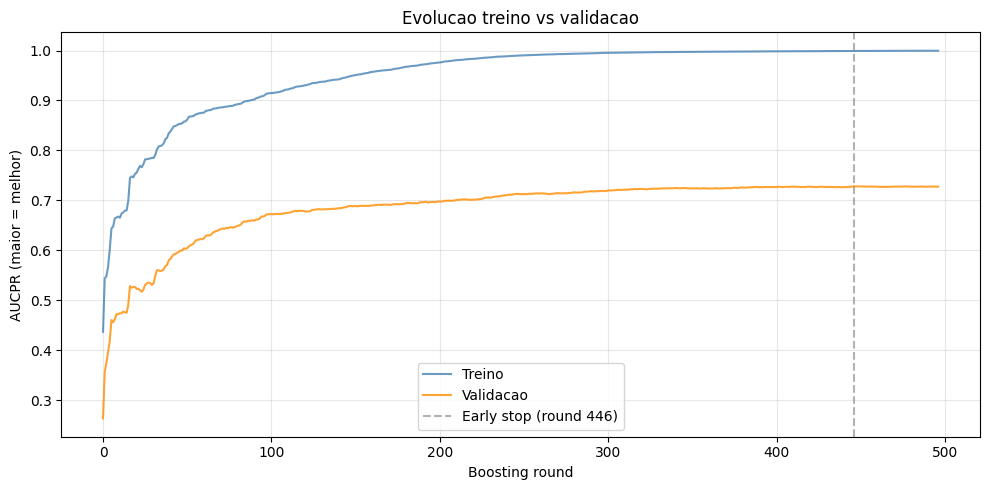


  Modelo final treinado.


In [12]:
# ---------------------------------------------------------------------
# Bloco 9 — Treinamento final do modelo
# ---------------------------------------------------------------------
#
# Com os hiperparametros otimizados pelo Optuna, treinamos o modelo
# definitivo usando todo o conjunto de treino. O conjunto de validacao
# e usado exclusivamente para o early stopping: a cada round de
# boosting, a metrica de validacao e monitorada. Se ela nao melhorar
# por 50 rounds consecutivos, o treinamento e interrompido. Isso
# evita que o modelo continue adicionando arvores que memorizam
# detalhes do treino sem melhorar a generalizacao.

print("=" * 70)
print("Treinamento final com melhores hiperparametros")
print("=" * 70)

# Verificacao de sanidade: garante que nenhuma coluna do tipo object
# (texto) permaneceu nos DataFrames de features. O DMatrix do XGBoost
# espera apenas valores numericos.
obj_train = X_train.select_dtypes(include=["object"]).columns.tolist()
obj_val = X_val.select_dtypes(include=["object"]).columns.tolist()

if obj_train or obj_val:
    raise ValueError(
        f"Existem colunas object antes do DMatrix.\n"
        f"X_train object: {obj_train}\n"
        f"X_val object: {obj_val}"
    )

# Verifica que o schema de features e identico entre treino e validacao.
# Se as colunas forem diferentes, o modelo seria treinado e avaliado
# em espacos de features distintos, invalidando tudo.
assert list(X_train.columns) == list(X_val.columns), \
    "Schema inconsistente entre treino e validacao."

# Extrai n_estimators (que nao e parametro nativo do xgb.train) e
# usa como num_boost_round. Os demais parametros sao passados no dict.
n_estimators_final = best_params.pop("n_estimators", 500)

xgb_final_params = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "tree_method": "hist",
    "verbosity": 0,
    "seed": SEED,
    **{k: v for k, v in best_params.items() if k != "n_estimators"},
}

# Converte para DMatrix (formato nativo do XGBoost), que e mais
# eficiente em memoria e velocidade que DataFrames pandas.
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=X_train.columns.tolist())
dval = xgb.DMatrix(X_val, label=y_val, feature_names=X_val.columns.tolist())

# evals_result armazena a evolucao da metrica a cada round para
# ambos os conjuntos, permitindo visualizar a curva de aprendizado.
evals_result = {}
final_model = xgb.train(
    xgb_final_params,
    dtrain,
    num_boost_round=n_estimators_final,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=50,
    evals_result=evals_result,
    verbose_eval=False,
)

print(f"  Melhor iteracao (early stopping): {final_model.best_iteration}")
print(f"  AUCPR na validacao: {final_model.best_score:.4f}")

# Grafico da evolucao da metrica: permite diagnosticar overfitting.
# Se a curva de treino continua subindo mas a de validacao estagna
# ou cai, ha overfitting. O early stopping interrompe no ponto ideal.
fig, ax = plt.subplots(figsize=(10, 5))
rounds = range(len(evals_result["train"]["aucpr"]))
ax.plot(rounds, evals_result["train"]["aucpr"], label="Treino", alpha=0.8, color="steelblue")
ax.plot(rounds, evals_result["val"]["aucpr"], label="Validacao", alpha=0.8, color="darkorange")
ax.axvline(
    final_model.best_iteration,
    color="gray", ls="--", alpha=0.6,
    label=f"Early stop (round {final_model.best_iteration})"
)
ax.set_xlabel("Boosting round")
ax.set_ylabel("AUCPR (maior = melhor)")
ax.set_title("Evolucao treino vs validacao")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

print("\n  Modelo final treinado.")

Avaliacao final no hold-out test

  Metricas do XGBoost no hold-out:
    ROC-AUC        : 0.8907
    PR-AUC         : 0.7072
    Precision@0.50 : 0.6175
    Recall@0.50    : 0.6686
    F1@0.50        : 0.6420
    Log Loss       : 0.1970
    Brier Score    : 0.0528

  Comparacao com baselines (todos no teste):
    [+] XGB vs Dummy (ROC-AUC): +0.3680
    [+] XGB vs Dummy (PR-AUC): +0.6077
    [+] XGB vs Dummy (F1@0.50): +0.5068
    [+] XGB vs LogisticReg (ROC-AUC): +0.1116
    [+] XGB vs LogisticReg (PR-AUC): +0.4315
    [+] XGB vs LogisticReg (F1@0.50): +0.3203

  Matriz de confusao:
                    Previsto 0  Previsto 1
    Real 0             1561          70
    Real 1               56         113

  Classification report (@0.50):
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1631
           1       0.62      0.67      0.64       169

    accuracy                           0.93      1800
   macro avg       0.79      0.81  

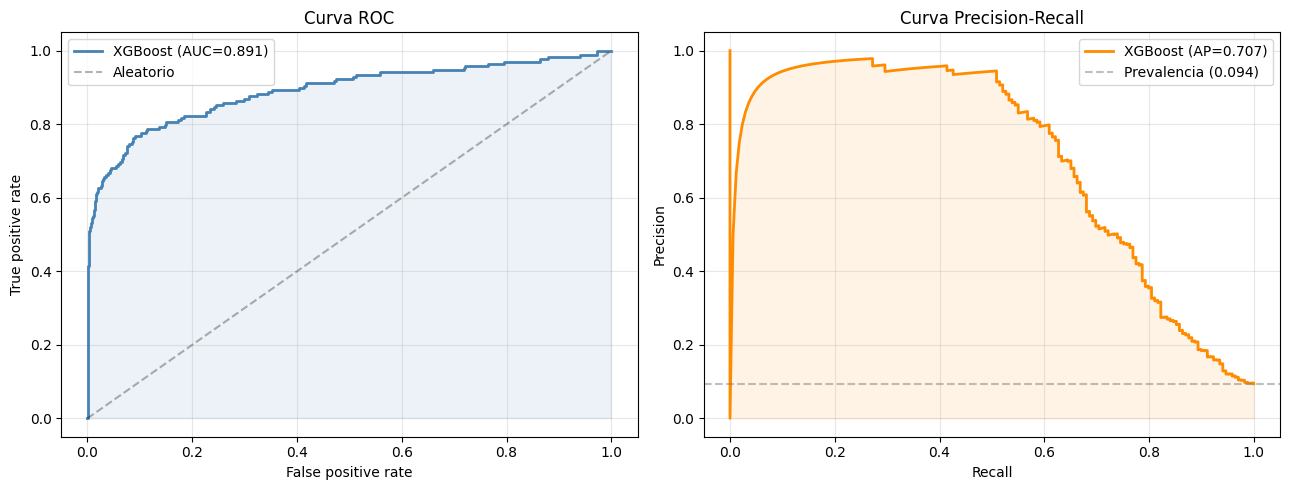


  Avaliacao completa.


In [13]:
# ---------------------------------------------------------------------
# Bloco 10 — Avaliacao final no hold-out test
# ---------------------------------------------------------------------
#
# Este e o primeiro e unico momento em que o modelo XGBoost ve o
# conjunto de teste. A performance obtida aqui e a estimativa mais
# honesta da performance em dados nunca vistos.
#
# Metricas utilizadas:
#
#   ROC-AUC: mede a capacidade do modelo de ordenar positivos acima
#   de negativos. Varia de 0.5 (aleatorio) a 1.0 (perfeito). E
#   invariante ao threshold escolhido.
#
#   PR-AUC (average precision): area sob a curva precision-recall.
#   Especialmente informativa em dados desbalanceados porque foca na
#   performance da classe minoritaria, sem ser inflada pela abundancia
#   de verdadeiros negativos.
#
#   Precision: entre as observacoes classificadas como positivas, qual
#   fracao e realmente positiva. Alta precision = poucos falsos alarmes.
#
#   Recall: entre as observacoes realmente positivas, qual fracao foi
#   detectada pelo modelo. Alto recall = poucos positivos perdidos.
#
#   F1: media harmonica entre precision e recall. Equilibra ambas as
#   perspectivas em um unico numero.
#
#   Log Loss: penaliza previsoes confiantes que estao erradas. Um
#   modelo que atribui probabilidade 0.99 a um caso negativo e
#   fortemente penalizado.
#
#   Brier Score: erro quadratico medio entre a probabilidade prevista
#   e o resultado real (0 ou 1). Mede a qualidade da calibracao.
#   Menor e melhor.

print("=" * 70)
print("Avaliacao final no hold-out test")
print("=" * 70)

# Verifica que o schema de features e identico nos tres conjuntos
assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns), \
    "Schema inconsistente entre splits."

# Converte o teste para DMatrix
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=feature_cols)

# Calcula o limite superior do iteration_range.
# best_iteration e 0-based, entao somamos 1 para incluir essa iteracao.
best_iter_final = final_model.best_iteration + 1 if final_model.best_iteration is not None else n_estimators_final

# Gera probabilidades e previsoes binarias com threshold padrao 0.5
test_proba_raw = final_model.predict(dtest, iteration_range=(0, best_iter_final))
test_pred_raw_05 = (test_proba_raw >= 0.5).astype(int)

# Calcula todas as metricas
test_metrics_raw = {
    "ROC-AUC": roc_auc_score(y_test, test_proba_raw),
    "PR-AUC": average_precision_score(y_test, test_proba_raw),
    "Precision@0.50": precision_score(y_test, test_pred_raw_05, zero_division=0),
    "Recall@0.50": recall_score(y_test, test_pred_raw_05, zero_division=0),
    "F1@0.50": f1_score(y_test, test_pred_raw_05, zero_division=0),
    "Log Loss": log_loss(y_test, test_proba_raw),
    "Brier Score": brier_score_loss(y_test, test_proba_raw),
}

print(f"\n  Metricas do XGBoost no hold-out:")
for k, v in test_metrics_raw.items():
    print(f"    {k:15s}: {v:.4f}")

# Compara com os baselines para quantificar o ganho do XGBoost
print(f"\n  Comparacao com baselines (todos no teste):")
for bl_name, bl_metrics in baseline_results_test.items():
    for m_model, m_base in [("ROC-AUC", "ROC-AUC"), ("PR-AUC", "PR-AUC"), ("F1@0.50", "F1")]:
        if m_base in bl_metrics and m_model in test_metrics_raw:
            delta = test_metrics_raw[m_model] - bl_metrics[m_base]
            status = "[+]" if delta > 0 else "[-]"
            print(f"    {status} XGB vs {bl_name} ({m_model}): {delta:+.4f}")

# Matriz de confusao: mostra a contagem de acertos e erros por classe.
# TN = verdadeiros negativos, FP = falsos positivos (alarmes falsos),
# FN = falsos negativos (positivos perdidos), TP = verdadeiros positivos.
cm = confusion_matrix(y_test, test_pred_raw_05)
tn, fp, fn, tp = cm.ravel()

print(f"\n  Matriz de confusao:")
print(f"    {'':15s} Previsto 0  Previsto 1")
print(f"    {'Real 0':15s}   {tn:5d}       {fp:5d}")
print(f"    {'Real 1':15s}   {fn:5d}       {tp:5d}")

print(f"\n  Classification report (@0.50):")
print(classification_report(y_test, test_pred_raw_05, zero_division=0))

# Graficos das curvas ROC e Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Curva ROC: eixo X = taxa de falsos positivos, eixo Y = taxa de
# verdadeiros positivos. A diagonal representa um classificador
# aleatorio.
fpr, tpr, _ = roc_curve(y_test, test_proba_raw)
axes[0].plot(fpr, tpr, lw=2, color="steelblue", label=f"XGBoost (AUC={test_metrics_raw['ROC-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Aleatorio")
axes[0].fill_between(fpr, tpr, alpha=0.1, color="steelblue")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("Curva ROC")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Curva Precision-Recall: eixo X = recall, eixo Y = precision.
# A linha horizontal pontilhada representa a prevalencia da classe
# positiva (baseline de um classificador que preve tudo como positivo).
prec_curve, rec_curve, _ = precision_recall_curve(y_test, test_proba_raw)
prevalence = y_test.mean()
axes[1].plot(rec_curve, prec_curve, lw=2, color="darkorange", label=f"XGBoost (AP={test_metrics_raw['PR-AUC']:.3f})")
axes[1].axhline(prevalence, color="gray", ls="--", alpha=0.5, label=f"Prevalencia ({prevalence:.3f})")
axes[1].fill_between(rec_curve, prec_curve, alpha=0.1, color="darkorange")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

# DataFrame auxiliar para analises posteriores
test_eval_df = pd.DataFrame({
    "y_true": y_test.values,
    "proba_raw": test_proba_raw,
    "pred_raw_05": test_pred_raw_05,
})

print(f"\n  Avaliacao completa.")

In [14]:
# ---------------------------------------------------------------------
# Bloco 11 — Analise por subgrupo
# ---------------------------------------------------------------------
#
# Um modelo pode apresentar boa performance agregada e falhar em
# segmentos especificos da populacao. Por exemplo, uma AUC global de
# 0.85 pode esconder uma AUC de 0.60 para uma determinada regiao.
# Esse tipo de disparidade e inaceitavel em muitos contextos de
# negocio e regulatorios.
#
# Esta analise verifica a performance do modelo em diferentes
# subgrupos definidos pelas variaveis categoricas originais e por
# faixas de score do proprio modelo.

print("=" * 70)
print("Analise por subgrupo")
print("=" * 70)

# Reune as informacoes necessarias em um unico DataFrame: target
# real, probabilidade prevista e os valores categoricos originais
# (antes do encoding). Os valores ausentes sao substituidos pela
# string "missing" para formar um grupo proprio.
df_subgroup = pd.DataFrame({
    "y_true": y_test.values,
    "proba_raw": test_proba_raw,
    "cat_region": test_meta["cat_region"].fillna("missing").values,
    "cat_channel": test_meta["cat_channel"].fillna("missing").values,
})

# --- Metricas por faixa de score ---
# Divide o score previsto em faixas e compara a media do score com
# a taxa real de positivos em cada faixa. Se o modelo estiver bem
# calibrado, essas duas quantidades devem ser proximas.
bins = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
df_subgroup["score_bin"] = pd.cut(df_subgroup["proba_raw"], bins=bins, include_lowest=True)

print(f"\n  Metricas por faixa de score:")
print(f"  {'Faixa':15s} | {'N':>6s} | {'Score medio':>11s} | {'Taxa real':>9s}")
print(f"  {'-' * 52}")
for b, grp in df_subgroup.groupby("score_bin", observed=True):
    if len(grp) < 10:
        continue
    print(f"  {str(b):15s} | {len(grp):6d} | {grp['proba_raw'].mean():11.3f} | {grp['y_true'].mean():9.3f}")


def summarize_subgroup_metrics(
    df_in: pd.DataFrame,
    group_col: str,
    min_n: int = 30,
    min_pos: int = 5,
    min_neg: int = 5,
):
    '''Calcula metricas de performance para cada subgrupo.

    Filtra subgrupos com tamanho insuficiente (min_n) ou com poucas
    observacoes de uma das classes (min_pos, min_neg) para evitar
    metricas instáveis. ROC-AUC e PR-AUC exigem pelo menos um
    positivo e um negativo para serem calculadas.
    '''
    rows = []
    for grp_name, grp in df_in.groupby(group_col, dropna=False):
        n = len(grp)
        n_pos = int(grp["y_true"].sum())
        n_neg = n - n_pos

        if n < min_n or n_pos < min_pos or n_neg < min_neg:
            continue

        rows.append({
            group_col: grp_name,
            "N": n,
            "Positivos": n_pos,
            "Taxa target": grp["y_true"].mean(),
            "ROC-AUC": roc_auc_score(grp["y_true"], grp["proba_raw"]),
            "PR-AUC": average_precision_score(grp["y_true"], grp["proba_raw"]),
            "Brier": brier_score_loss(grp["y_true"], grp["proba_raw"]),
        })

    if len(rows) == 0:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values("N", ascending=False)


region_summary = summarize_subgroup_metrics(df_subgroup, "cat_region")
channel_summary = summarize_subgroup_metrics(df_subgroup, "cat_channel")

print(f"\n  Metricas por regiao:")
if not region_summary.empty:
    print(region_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
else:
    print("  Sem grupos com tamanho minimo suficiente.")

print(f"\n  Metricas por canal:")
if not channel_summary.empty:
    print(channel_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
else:
    print("  Sem grupos com tamanho minimo suficiente.")

Analise por subgrupo

  Metricas por faixa de score:
  Faixa           |      N | Score medio | Taxa real
  ----------------------------------------------------
  (-0.001, 0.1]   |   1333 |       0.025 |     0.023
  (0.1, 0.3]      |    219 |       0.176 |     0.068
  (0.3, 0.5]      |     65 |       0.402 |     0.169
  (0.5, 0.7]      |     56 |       0.597 |     0.214
  (0.7, 0.9]      |     48 |       0.804 |     0.562
  (0.9, 1.0]      |     79 |       0.970 |     0.937

  Metricas por regiao:
cat_region   N  Positivos  Taxa target  ROC-AUC  PR-AUC  Brier
     norte 446         39       0.0874   0.8419  0.6969 0.0568
     leste 421         32       0.0760   0.9480  0.7699 0.0385
     oeste 419         39       0.0931   0.9067  0.7007 0.0589
       sul 389         43       0.1105   0.8690  0.6928 0.0551
   missing 125         16       0.1280   0.9260  0.7994 0.0584

  Metricas por canal:
cat_channel   N  Positivos  Taxa target  ROC-AUC  PR-AUC  Brier
       loja 631         53      

Calibracao de probabilidades

  Escolha do calibrador feita no calibration-select:
  method  brier_select  logloss_select  pr_auc_select
   platt      0.044385        0.169473       0.731275
isotonic      0.047699        0.280290       0.675029

  Calibrador escolhido: platt

  Brier no teste (descritivo, sem usar para escolher metodo):
    Raw      : 0.0528
    platt    : 0.0448


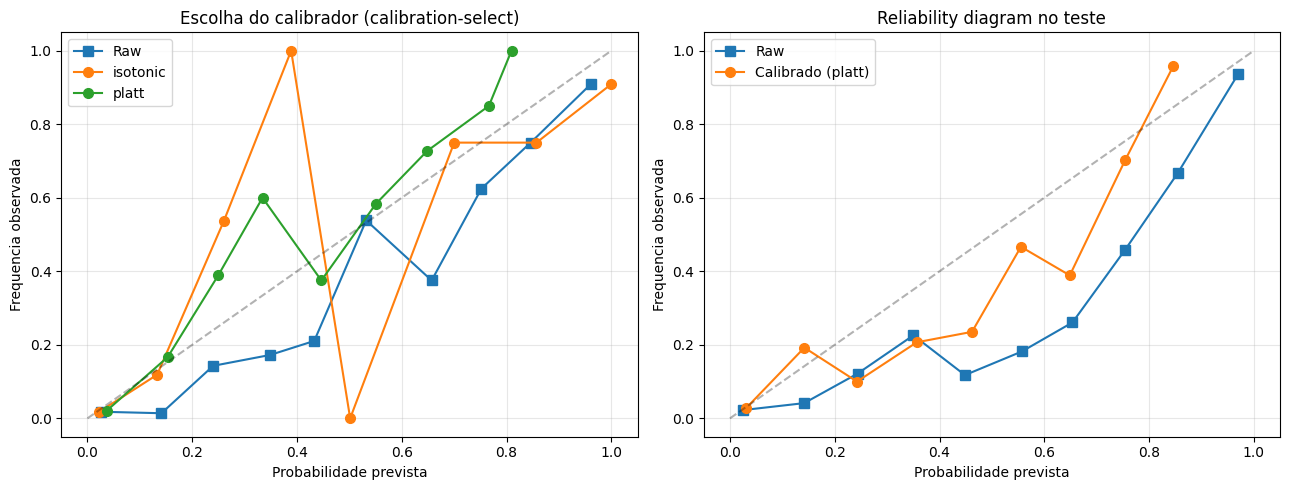

In [15]:
# ---------------------------------------------------------------------
# Bloco 12 — Calibracao de probabilidades
# ---------------------------------------------------------------------
#
# Quando o modelo atribui probabilidade de 70% a uma observacao,
# espera-se que, entre todas as observacoes com score proximo de 70%,
# aproximadamente 70% sejam de fato positivas. Se isso nao ocorre,
# as probabilidades estao mal calibradas.
#
# Uma AUC alta nao garante boa calibracao. A AUC mede apenas a
# capacidade de ordenacao (ranking), nao o valor absoluto das
# probabilidades. Decisoes de negocio que dependem de limiares
# absolutos (por exemplo, "aprovar se P(default) < 5%") exigem
# probabilidades calibradas.
#
# Para calibrar, ajustamos um modelo simples que transforma os scores
# crus do XGBoost em probabilidades melhor calibradas. Usamos dois
# metodos e selecionamos o melhor:
#
#   Isotonic regression: ajuste nao-parametrico que aprende uma funcao
#   escada monotonica. E flexivel, mas pode sofrer overfitting com
#   poucas observacoes positivas.
#
#   Platt scaling (sigmoid): ajuste parametrico que aplica uma
#   regressao logistica sobre os scores. E mais estavel com amostras
#   pequenas, mas assume que a relacao entre score e probabilidade
#   real segue uma sigmoide.
#
# Para evitar viés na selecao do calibrador, dividimos o conjunto de
# validacao em duas metades:
#   - calibration-fit: usada para ajustar ambos os calibradores
#   - calibration-select: usada para escolher o melhor metodo
# Nenhum dado de teste e usado nesta decisao.

print("=" * 70)
print("Calibracao de probabilidades")
print("=" * 70)

# Gera os scores crus do modelo final na validacao inteira
dval_full = xgb.DMatrix(X_val, label=y_val, feature_names=feature_cols)
val_proba_raw = final_model.predict(dval_full, iteration_range=(0, best_iter_final))

# Divide a validacao em duas metades estratificadas
cal_fit_idx, cal_select_idx = train_test_split(
    np.arange(len(y_val)),
    test_size=0.50,
    stratify=y_val,
    random_state=SEED,
)

y_cal_fit = y_val.iloc[cal_fit_idx].reset_index(drop=True)
y_cal_select = y_val.iloc[cal_select_idx].reset_index(drop=True)

proba_cal_fit_raw = val_proba_raw[cal_fit_idx]
proba_cal_select_raw = val_proba_raw[cal_select_idx]


def fit_calibrator(method: str, scores: np.ndarray, y_true: np.ndarray):
    '''Ajusta um calibrador sobre scores e targets fornecidos.

    Para isotonic: ajusta uma regressao isotonica que mapeia scores
    em probabilidades via funcao monotonica nao-decrescente.
    Para platt: ajusta uma regressao logistica unidimensional sobre
    os scores, aprendendo uma transformacao sigmoidal.
    '''
    if method == "isotonic":
        model = IsotonicRegression(out_of_bounds="clip")
        model.fit(scores, y_true)
        return model
    elif method == "platt":
        model = LogisticRegression(max_iter=1000, random_state=SEED)
        model.fit(scores.reshape(-1, 1), y_true)
        return model
    else:
        raise ValueError(f"Metodo de calibracao desconhecido: {method}")


def apply_calibrator(model, method: str, scores: np.ndarray) -> np.ndarray:
    '''Aplica um calibrador ja ajustado para transformar scores.'''
    if method == "isotonic":
        return np.clip(model.predict(scores), 0, 1)
    elif method == "platt":
        return model.predict_proba(scores.reshape(-1, 1))[:, 1]
    else:
        raise ValueError(f"Metodo de calibracao desconhecido: {method}")


# Etapa 1: ajusta ambos os calibradores na metade fit
# Etapa 2: avalia ambos na metade select
selection_rows = []
holdout_calibrators = {}

for method in ["isotonic", "platt"]:
    cal_model = fit_calibrator(method, proba_cal_fit_raw, y_cal_fit.values)
    holdout_calibrators[method] = cal_model

    proba_select_cal = apply_calibrator(cal_model, method, proba_cal_select_raw)

    selection_rows.append({
        "method": method,
        "brier_select": brier_score_loss(y_cal_select, proba_select_cal),
        "logloss_select": log_loss(y_cal_select, proba_select_cal),
        "pr_auc_select": average_precision_score(y_cal_select, proba_select_cal),
    })

# Seleciona o metodo com menor Brier score na metade select.
# Em caso de empate, usa log loss e PR-AUC como desempate.
selection_df = pd.DataFrame(selection_rows).sort_values(
    ["brier_select", "logloss_select", "pr_auc_select"],
    ascending=[True, True, False]
)

cal_method = selection_df.iloc[0]["method"]
selected_calibrator_holdout = holdout_calibrators[cal_method]
proba_cal_select_calibrated = apply_calibrator(
    selected_calibrator_holdout, cal_method, proba_cal_select_raw
)

print("\n  Escolha do calibrador feita no calibration-select:")
print(selection_df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print(f"\n  Calibrador escolhido: {cal_method}")

# Apos escolher o metodo, reajusta o calibrador vencedor na validacao
# completa para aproveitar todos os dados disponiveis.
iso_reg = fit_calibrator("isotonic", val_proba_raw, y_val.values)
platt = fit_calibrator("platt", val_proba_raw, y_val.values)

final_calibrator = iso_reg if cal_method == "isotonic" else platt

# Aplica o calibrador final na validacao e no teste
val_proba_calibrated = apply_calibrator(final_calibrator, cal_method, val_proba_raw)
test_proba_calibrated = apply_calibrator(final_calibrator, cal_method, test_proba_raw)

print(f"\n  Brier no teste (descritivo, sem usar para escolher metodo):")
print(f"    Raw      : {brier_score_loss(y_test, test_proba_raw):.4f}")
print(f"    {cal_method:9s}: {brier_score_loss(y_test, test_proba_calibrated):.4f}")

# Reliability diagrams: mostram a calibracao visual do modelo.
# O eixo X e a probabilidade prevista (agrupada em bins) e o eixo Y
# e a frequencia real observada. Um modelo perfeitamente calibrado
# acompanha a diagonal.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Painel esquerdo: comparacao dos metodos no calibration-select
prob_true_raw_sel, prob_pred_raw_sel = calibration_curve(y_cal_select, proba_cal_select_raw, n_bins=10, strategy="uniform")
axes[0].plot(prob_pred_raw_sel, prob_true_raw_sel, "s-", label="Raw", markersize=7)

for method in ["isotonic", "platt"]:
    proba_sel_cal = apply_calibrator(holdout_calibrators[method], method, proba_cal_select_raw)
    prob_true_sel, prob_pred_sel = calibration_curve(y_cal_select, proba_sel_cal, n_bins=10, strategy="uniform")
    axes[0].plot(prob_pred_sel, prob_true_sel, "o-", label=method, markersize=7)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_title("Escolha do calibrador (calibration-select)")
axes[0].set_xlabel("Probabilidade prevista")
axes[0].set_ylabel("Frequencia observada")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Painel direito: raw vs calibrado no teste (apenas relatorio visual)
prob_true_test_raw, prob_pred_test_raw = calibration_curve(y_test, test_proba_raw, n_bins=10, strategy="uniform")
prob_true_test_cal, prob_pred_test_cal = calibration_curve(y_test, test_proba_calibrated, n_bins=10, strategy="uniform")

axes[1].plot(prob_pred_test_raw, prob_true_test_raw, "s-", label="Raw", markersize=7)
axes[1].plot(prob_pred_test_cal, prob_true_test_cal, "o-", label=f"Calibrado ({cal_method})", markersize=7)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_title("Reliability diagram no teste")
axes[1].set_xlabel("Probabilidade prevista")
axes[1].set_ylabel("Frequencia observada")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

Analise de threshold (ponto de corte)

  Thresholds encontrados no calibration-select:
    Maximiza F1                          : 0.26
    Maximiza F-beta (beta=2.0)         : 0.14
    Max Recall com Precision >= 30%   : 0.05
    Minimiza custo (FN=10x / FP=1x)      : 0.23

  Threshold selecionado (F-beta): 0.14

  Comparacao no teste com os 4 criterios:
  Criterio                            |     F1 | Precision | Recall
  -----------------------------------------------------------------
  F1                    (t=0.26)      | 0.6441 |    0.6162 | 0.6746
  F-beta beta=2.0       (t=0.14)      | 0.5985 |    0.5172 | 0.7101
  Max Recall P>=30%    (t=0.05)       | 0.4928 |    0.3551 | 0.8047
  Min Custo FN=10x/FP=1x  (t=0.23)    | 0.6284 |    0.5838 | 0.6805
  Baseline              (t=0.50)      | 0.6821 |    0.7744 | 0.6095


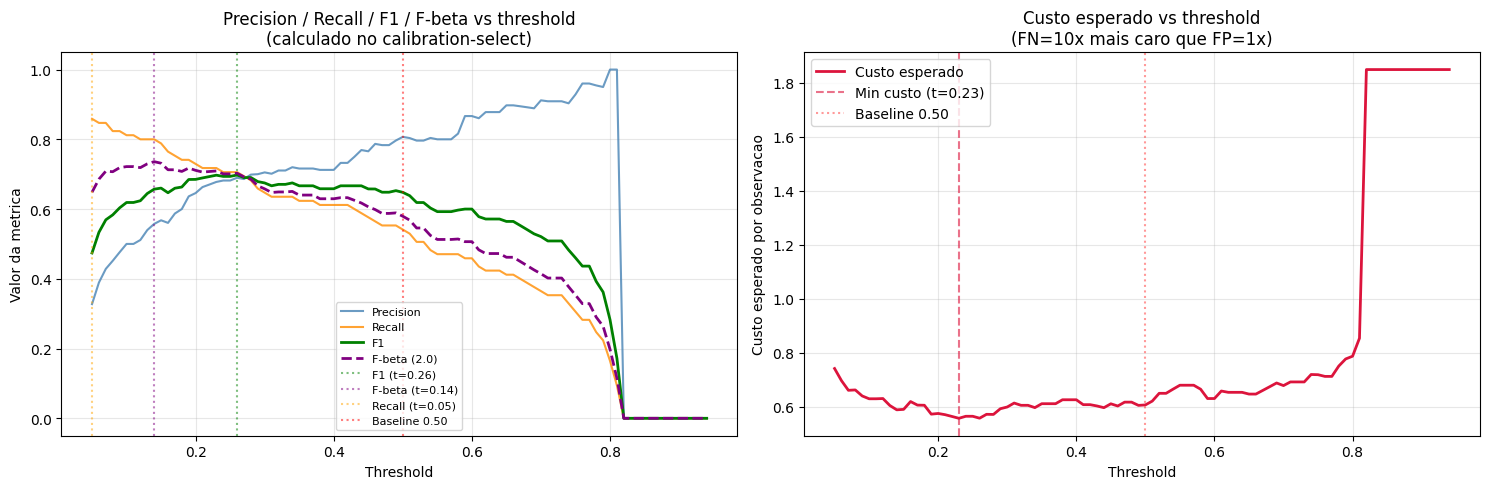


  Threshold final exportado para os proximos blocos: 0.14


In [16]:
# ---------------------------------------------------------------------
# Bloco 13 — Analise de threshold (ponto de corte) — versao estendida
# ---------------------------------------------------------------------
#
# O modelo retorna uma probabilidade para cada observacao. Para tomar
# uma decisao binaria (aprovar/reprovar, tratar/nao tratar), e
# necessario escolher um ponto de corte: "se a probabilidade for
# maior ou igual ao threshold, classifico como positivo."
#
# O threshold padrao de 0.5 e razoavel em problemas balanceados, mas
# em problemas desbalanceados pode resultar em recall muito baixo
# (o modelo nunca preve a classe rara).
#
# A escolha do threshold e uma decisao de negocio que depende dos
# custos relativos dos erros:
#   - Se perder um positivo e muito grave (diagnostico de cancer,
#     deteccao de fraude), usar threshold baixo para maximizar recall
#     (ao custo de mais falsos alarmes).
#   - Se um falso alarme e caro (bloqueio de conta, envio de equipe
#     de campo), usar threshold alto para maximizar precision (ao
#     custo de perder alguns positivos).
#
# Avaliamos quatro criterios de selecao de threshold, todos calculados
# no calibration-select (subconjunto da validacao), e apenas aplicados
# no teste para evitar leakage na escolha do ponto de operacao:
#
#   Criterio 1 — Maximiza F1: equilibra precision e recall com pesos
#   iguais. Adequado quando os dois tipos de erro tem custo similar.
#
#   Criterio 2 — Maximiza F-beta: generaliza o F1 permitindo pesos
#   diferentes entre precision e recall. Com beta > 1, erros de recall
#   (falsos negativos) pesam mais. Com beta < 1, erros de precision
#   (falsos positivos) pesam mais.
#
#   Criterio 3 — Maximiza recall com precision minima garantida:
#   util quando o negocio exige capturar o maximo de positivos, mas
#   impoem um limite inferior para a taxa de acerto nas previsoes
#   positivas (por exemplo, "nunca caia abaixo de 30% de precision").
#
#   Criterio 4 — Minimiza custo esperado: usa os custos absolutos de
#   falsos negativos e falsos positivos para encontrar o threshold que
#   minimiza o prejuizo esperado por observacao. E o criterio mais
#   diretamente alinhado com o impacto de negocio.

print("=" * 70)
print("Analise de threshold (ponto de corte)")
print("=" * 70)

# --- Parametros de negocio ---
# Estes valores devem ser ajustados para cada problema especifico.
# Centraliza-los aqui facilita a adaptacao sem alterar a logica abaixo.
#
# BETA: controla o peso relativo entre recall e precision no F-beta.
#   beta = 1.0 equivale ao F1 padrao (pesos iguais).
#   beta = 2.0 faz o recall valer o dobro da precision (prioriza
#   capturar positivos, tolerando mais falsos alarmes).
#   beta = 0.5 faz a precision valer o dobro do recall (prioriza
#   qualidade das previsoes positivas, tolerando mais casos perdidos).
BETA = 2.0

# MIN_PRECISION: precision minima aceitavel para o criterio 3.
# Abaixo deste valor, o threshold sera considerado inviavel, pois
# geraria muitos falsos alarmes (ex: bloquear contas de clientes bons).
MIN_PRECISION = 0.30

# COST_FN: custo de um falso negativo (caso positivo nao detectado).
# COST_FP: custo de um falso positivo (alarme falso).
# A razao COST_FN / COST_FP define o quanto e mais grave errar para
# um lado do que para o outro. Exemplo: em deteccao de fraude, deixar
# passar uma fraude (FN) pode custar 10x mais do que bloquear uma
# transacao legitima (FP).
COST_FN = 10
COST_FP = 1

# Varre todos os thresholds de 0.05 a 0.94 em passos de 0.01 e
# calcula as metricas de interesse no calibration-select.
# O limite inferior de 0.05 evita thresholds que classificam
# praticamente tudo como positivo; o superior de 0.94 evita o oposto.
thresholds = np.arange(0.05, 0.95, 0.01)
threshold_rows = []

# Prevalencia da classe positiva no calibration-select: usada para
# calcular o custo esperado por observacao (criterio 4).
prevalence_cal = y_cal_select.mean()

for t in thresholds:
    # Converte probabilidades em previsoes binarias com o threshold t
    pred_sel = (proba_cal_select_calibrated >= t).astype(int)

    prec = precision_score(y_cal_select, pred_sel, zero_division=0)
    rec  = recall_score(y_cal_select, pred_sel, zero_division=0)
    f1   = f1_score(y_cal_select, pred_sel, zero_division=0)

    # F-beta: media harmonica ponderada entre precision e recall.
    # A constante 1e-9 no denominador evita divisao por zero quando
    # precision e recall sao simultaneamente zero (threshold extremo).
    fbeta = (
        (1 + BETA**2) * prec * rec
        / (BETA**2 * prec + rec + 1e-9)
    )

    # Custo esperado por observacao: combina a taxa de falsos negativos
    # ponderada pela prevalencia com a taxa de falsos positivos ponderada
    # pela frequencia da classe negativa. O resultado e interpretavel
    # como o prejuizo medio esperado para cada nova observacao.
    custo = (
        COST_FN * (1 - rec)  * prevalence_cal           # FN esperados
      + COST_FP * (1 - prec) * (1 - prevalence_cal)     # FP esperados
    )

    threshold_rows.append({
        "threshold": t,
        "precision": prec,
        "recall":    rec,
        "f1":        f1,
        "fbeta":     fbeta,
        "custo":     custo,
    })

threshold_df = pd.DataFrame(threshold_rows)

# --- Criterio 1: maximiza F1 ---
# Encontra o threshold onde a media harmonica entre precision e recall
# e maxima. Usa idxmax() para obter o indice da linha de maior F1.
best_t_f1 = float(threshold_df.loc[threshold_df["f1"].idxmax(), "threshold"])

# --- Criterio 2: maximiza F-beta ---
# Analogamente ao F1, mas com o peso entre precision e recall
# ajustado pelo parametro BETA definido acima.
best_t_fbeta = float(threshold_df.loc[threshold_df["fbeta"].idxmax(), "threshold"])

# --- Criterio 3: maximiza recall com precision minima garantida ---
# Filtra os thresholds que atendem ao requisito minimo de precision
# e, entre esses, seleciona o que produz o maior recall.
# Se nenhum threshold satisfaz o requisito, usa o criterio F1 como
# fallback e emite um aviso.
valid_prec = threshold_df[threshold_df["precision"] >= MIN_PRECISION]
if not valid_prec.empty:
    best_t_recall = float(valid_prec.loc[valid_prec["recall"].idxmax(), "threshold"])
else:
    best_t_recall = best_t_f1
    print(f"  Aviso: nenhum threshold atinge precision >= {MIN_PRECISION:.0%}.")
    print(f"  Usando threshold do F1 ({best_t_f1:.2f}) como fallback.")

# --- Criterio 4: minimiza custo esperado ---
# Encontra o threshold que minimiza o custo medio por observacao,
# considerando os custos assimetricos de FN e FP definidos acima.
best_t_custo = float(threshold_df.loc[threshold_df["custo"].idxmin(), "threshold"])

# Threshold final exportado para os blocos seguintes.
# Troque esta linha para usar um criterio diferente conforme o problema.
# Opcoes: best_t_f1, best_t_fbeta, best_t_recall, best_t_custo
best_threshold = best_t_fbeta

print(f"\n  Thresholds encontrados no calibration-select:")
print(f"    Maximiza F1                          : {best_t_f1:.2f}")
print(f"    Maximiza F-beta (beta={BETA:.1f})         : {best_t_fbeta:.2f}")
print(f"    Max Recall com Precision >= {MIN_PRECISION:.0%}   : {best_t_recall:.2f}")
print(f"    Minimiza custo (FN={COST_FN}x / FP={COST_FP}x)      : {best_t_custo:.2f}")
print(f"\n  Threshold selecionado (F-beta): {best_threshold:.2f}")

# --- Avaliacao no teste com todos os criterios ---
# O teste e avaliado aqui apenas para relatorio final. A escolha do
# threshold ja foi feita no calibration-select; estes numeros nao
# retroalimentam nenhuma decisao do pipeline.
print(f"\n  Comparacao no teste com os 4 criterios:")
print(f"  {'Criterio':35s} | {'F1':>6s} | {'Precision':>9s} | {'Recall':>6s}")
print(f"  {'-' * 65}")

criterios = [
    (f"F1                    (t={best_t_f1:.2f})",           best_t_f1),
    (f"F-beta beta={BETA:.1f}       (t={best_t_fbeta:.2f})", best_t_fbeta),
    (f"Max Recall P>={MIN_PRECISION:.0%}    (t={best_t_recall:.2f})",  best_t_recall),
    (f"Min Custo FN={COST_FN}x/FP={COST_FP}x  (t={best_t_custo:.2f})", best_t_custo),
    (f"Baseline              (t=0.50)",                       0.50),
]

for label, t in criterios:
    pred   = (test_proba_calibrated >= t).astype(int)
    f1_t   = f1_score(y_test, pred, zero_division=0)
    prec_t = precision_score(y_test, pred, zero_division=0)
    rec_t  = recall_score(y_test, pred, zero_division=0)
    print(f"  {label:35s} | {f1_t:6.4f} | {prec_t:9.4f} | {rec_t:6.4f}")

# --- Grafico 1: Precision / Recall / F1 / F-beta vs threshold ---
# Permite visualizar como cada metrica se comporta ao longo de todos
# os thresholds possiveis. As linhas verticais marcam os pontos
# otimos de cada criterio para comparacao direta.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(threshold_df["threshold"], threshold_df["precision"],
        label="Precision", color="steelblue", alpha=0.8)
ax.plot(threshold_df["threshold"], threshold_df["recall"],
        label="Recall", color="darkorange", alpha=0.8)
ax.plot(threshold_df["threshold"], threshold_df["f1"],
        label="F1", color="green", lw=2)
ax.plot(threshold_df["threshold"], threshold_df["fbeta"],
        label=f"F-beta ({BETA:.1f})", color="purple", lw=2, ls="--")

# Linhas verticais indicando o threshold otimo de cada criterio
for t, color, lbl in [
    (best_t_f1,     "green",  f"F1 (t={best_t_f1:.2f})"),
    (best_t_fbeta,  "purple", f"F-beta (t={best_t_fbeta:.2f})"),
    (best_t_recall, "orange", f"Recall (t={best_t_recall:.2f})"),
    (0.50,          "red",    "Baseline 0.50"),
]:
    ax.axvline(t, color=color, ls=":", alpha=0.5, label=lbl)

ax.set_xlabel("Threshold")
ax.set_ylabel("Valor da metrica")
ax.set_title("Precision / Recall / F1 / F-beta vs threshold\n(calculado no calibration-select)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Grafico 2: Custo esperado vs threshold ---
# Mostra como o custo medio por observacao varia com o threshold.
# O ponto de minimo corresponde ao threshold que minimiza o prejuizo
# esperado dado os custos de FN e FP definidos acima.
ax2 = axes[1]
ax2.plot(threshold_df["threshold"], threshold_df["custo"],
         color="crimson", lw=2, label="Custo esperado")
ax2.axvline(best_t_custo, color="crimson", ls="--", alpha=0.6,
            label=f"Min custo (t={best_t_custo:.2f})")
ax2.axvline(0.50, color="red", ls=":", alpha=0.4,
            label="Baseline 0.50")
ax2.set_xlabel("Threshold")
ax2.set_ylabel("Custo esperado por observacao")
ax2.set_title(
    f"Custo esperado vs threshold\n"
    f"(FN={COST_FN}x mais caro que FP={COST_FP}x)"
)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

print(f"\n  Threshold final exportado para os proximos blocos: {best_threshold:.2f}")

Top-k / Lift / Gain

  Total de observacoes : 1,800
  Total de positivos   : 169
  Prevalencia          : 0.0939
  Threshold de referencia: 0.14

  Desempenho por top-k:
top_frac top_pct_label    n  tp precision recall   lift score_min_no_top score_mean_no_top
    0.01            1%   18  17    0.9444 0.1006 10.06x           0.8592            0.8620
    0.05            5%   90  85    0.9444 0.5030 10.06x           0.7444            0.8329
    0.10           10%  180 113    0.6278 0.6686  6.69x           0.2951            0.6705
    0.20           20%  360 134    0.3722 0.7929  3.96x           0.0564            0.3954
    0.30           30%  540 143    0.2648 0.8462  2.82x           0.0349            0.2776
    0.50           50%  900 154    0.1711 0.9112  1.82x           0.0269            0.1784
    1.00          100% 1800 169    0.0939 1.0000  1.00x           0.0230            0.1014

  Tabela por decil do ranking:
decil   n  positivos taxa_real score_medio score_min score_max  lift
 

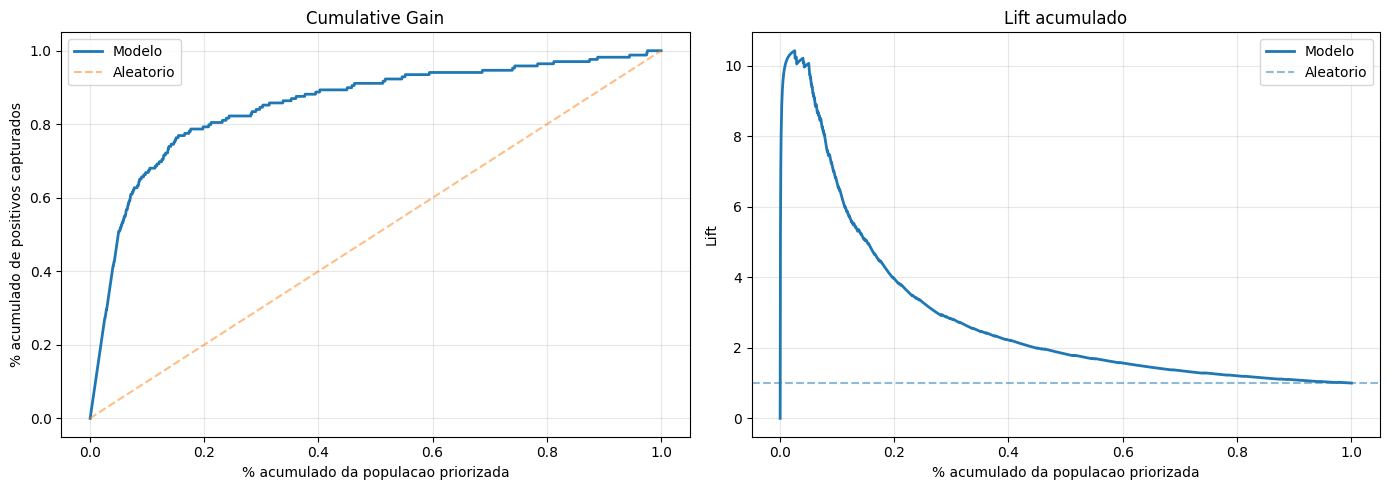

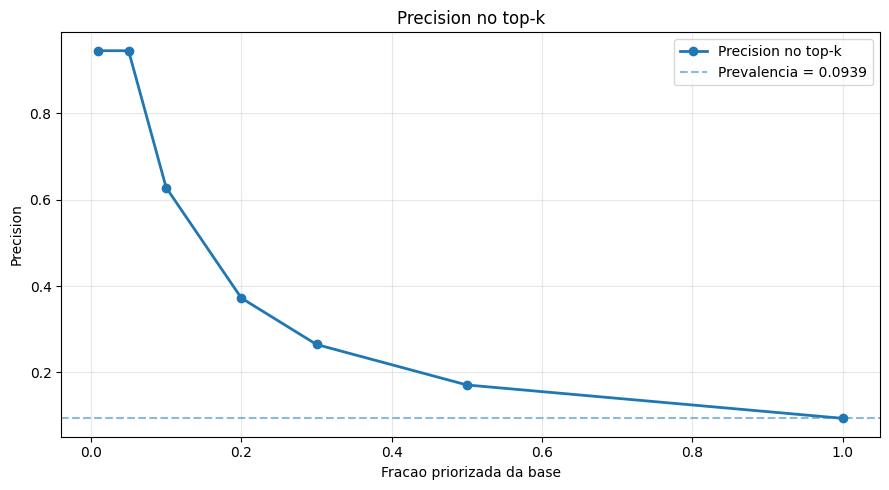


  Leitura rapida:
    - Se o lift no top 10% for 3.5x, o topo do ranking concentra 3.5 vezes mais positivos que a media da base.
    - Se o top 20% recuperar 70% dos positivos, seu modelo serve bem para priorizacao.
    - Se a curva de gain ficar perto da diagonal, o ranking tem pouco valor pratico.


In [17]:
# ---------------------------------------------------------------------
# Bloco 14A — Top-k / Lift / Gain
# ---------------------------------------------------------------------

print("=" * 70)
print("Top-k / Lift / Gain")
print("=" * 70)

# ------------------------------------------------------------
# 1) Escolher score principal
# ------------------------------------------------------------
if "test_proba_calibrated" in globals():
    score_name = "proba_calibrated"
    score = np.asarray(test_proba_calibrated)
elif "test_proba_raw" in globals():
    score_name = "proba_raw"
    score = np.asarray(test_proba_raw)
else:
    raise ValueError("Nao encontrei 'test_proba_calibrated' nem 'test_proba_raw'.")

# Threshold apenas para referencia
threshold_used = best_threshold if "best_threshold" in globals() else 0.50

# ------------------------------------------------------------
# 2) Base ordenada por score
# ------------------------------------------------------------
df_rank = pd.DataFrame({
    "y_true": np.asarray(y_test),
    "score": score,
}).sort_values("score", ascending=False).reset_index(drop=True)

df_rank["rank"] = np.arange(1, len(df_rank) + 1)
df_rank["cum_positives"] = df_rank["y_true"].cumsum()
df_rank["cum_population_pct"] = df_rank["rank"] / len(df_rank)
df_rank["cum_recall"] = df_rank["cum_positives"] / max(df_rank["y_true"].sum(), 1)
df_rank["cum_precision"] = df_rank["cum_positives"] / df_rank["rank"]

base_rate = df_rank["y_true"].mean()

print(f"\n  Total de observacoes : {len(df_rank):,}")
print(f"  Total de positivos   : {int(df_rank['y_true'].sum()):,}")
print(f"  Prevalencia          : {base_rate:.4f}")
print(f"  Threshold de referencia: {threshold_used:.2f}")

# ------------------------------------------------------------
# 3) Top-k summary
# ------------------------------------------------------------
top_fracs = [0.01, 0.05, 0.10, 0.20, 0.30, 0.50, 1.00]
top_rows = []

for frac in top_fracs:
    k = max(1, int(np.ceil(len(df_rank) * frac)))
    top_slice = df_rank.iloc[:k]

    tp_top = int(top_slice["y_true"].sum())
    precision_top = top_slice["y_true"].mean()
    recall_top = tp_top / max(int(df_rank["y_true"].sum()), 1)
    lift_top = precision_top / max(base_rate, 1e-12)

    top_rows.append({
        "top_frac": frac,
        "top_pct_label": f"{int(frac * 100)}%",
        "n": k,
        "tp": tp_top,
        "precision": precision_top,
        "recall": recall_top,
        "lift": lift_top,
        "score_min_no_top": float(top_slice["score"].min()),
        "score_mean_no_top": float(top_slice["score"].mean()),
    })

topk_df = pd.DataFrame(top_rows)

print("\n  Desempenho por top-k:")
print(
    topk_df.to_string(
        index=False,
        formatters={
            "top_frac": lambda x: f"{x:.2f}",
            "precision": lambda x: f"{x:.4f}",
            "recall": lambda x: f"{x:.4f}",
            "lift": lambda x: f"{x:.2f}x",
            "score_min_no_top": lambda x: f"{x:.4f}",
            "score_mean_no_top": lambda x: f"{x:.4f}",
        }
    )
)

# ------------------------------------------------------------
# 4) Tabela por decil
# ------------------------------------------------------------
df_rank["decil"] = pd.qcut(
    df_rank["rank"],
    q=10,
    labels=[f"D{i}" for i in range(1, 11)],
)

decil_df = (
    df_rank.groupby("decil", observed=True)
    .agg(
        n=("y_true", "size"),
        positivos=("y_true", "sum"),
        taxa_real=("y_true", "mean"),
        score_medio=("score", "mean"),
        score_min=("score", "min"),
        score_max=("score", "max"),
    )
    .reset_index()
)

decil_df["lift"] = decil_df["taxa_real"] / max(base_rate, 1e-12)

print("\n  Tabela por decil do ranking:")
print(
    decil_df.to_string(
        index=False,
        formatters={
            "taxa_real": lambda x: f"{x:.4f}",
            "score_medio": lambda x: f"{x:.4f}",
            "score_min": lambda x: f"{x:.4f}",
            "score_max": lambda x: f"{x:.4f}",
            "lift": lambda x: f"{x:.2f}x",
        }
    )
)

# ------------------------------------------------------------
# 5) Curvas: cumulative gain e lift
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gain curve
axes[0].plot(
    df_rank["cum_population_pct"],
    df_rank["cum_recall"],
    lw=2,
    label="Modelo",
)
axes[0].plot(
    [0, 1],
    [0, 1],
    ls="--",
    alpha=0.5,
    label="Aleatorio",
)
axes[0].set_title("Cumulative Gain")
axes[0].set_xlabel("% acumulado da populacao priorizada")
axes[0].set_ylabel("% acumulado de positivos capturados")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Lift curve
lift_curve = df_rank["cum_precision"] / max(base_rate, 1e-12)
axes[1].plot(
    df_rank["cum_population_pct"],
    lift_curve,
    lw=2,
    label="Modelo",
)
axes[1].axhline(1.0, ls="--", alpha=0.5, label="Aleatorio")
axes[1].set_title("Lift acumulado")
axes[1].set_xlabel("% acumulado da populacao priorizada")
axes[1].set_ylabel("Lift")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

# ------------------------------------------------------------
# 6) Grafico de precision por top-k
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(topk_df["top_frac"], topk_df["precision"], marker="o", lw=2, label="Precision no top-k")
ax.axhline(base_rate, ls="--", alpha=0.5, label=f"Prevalencia = {base_rate:.4f}")
ax.set_title("Precision no top-k")
ax.set_xlabel("Fracao priorizada da base")
ax.set_ylabel("Precision")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

print("\n  Leitura rapida:")
print("    - Se o lift no top 10% for 3.5x, o topo do ranking concentra 3.5 vezes mais positivos que a media da base.")
print("    - Se o top 20% recuperar 70% dos positivos, seu modelo serve bem para priorizacao.")
print("    - Se a curva de gain ficar perto da diagonal, o ranking tem pouco valor pratico.")

Error analysis — FP / FN

  Score usado     : proba_calibrated
  Threshold usado : 0.14

  Contagem por tipo de resultado:
    TP: 120
    FP: 112
    FN: 49
    TN: 1519

  Taxas:
    Precision = 0.5172
    Recall    = 0.7101
    F1        = 0.5985

----------------------------------------------------------------------
Perfil por cat_region
----------------------------------------------------------------------
cat_region  FN  FP  TN  TP   N FP_rate_dentro_pred_positivo FN_rate_dentro_real_positivo erro_total_rate
     norte  10  34 373  29 446                       0.5397                       0.2564          0.0987
     leste   9  20 369  23 421                       0.4651                       0.2812          0.0689
     oeste  11  32 348  28 419                       0.5333                       0.2821          0.1026
       sul  14  19 327  29 389                       0.3958                       0.3256          0.0848
       NaN   5   7 102  11 125                       0.3889 

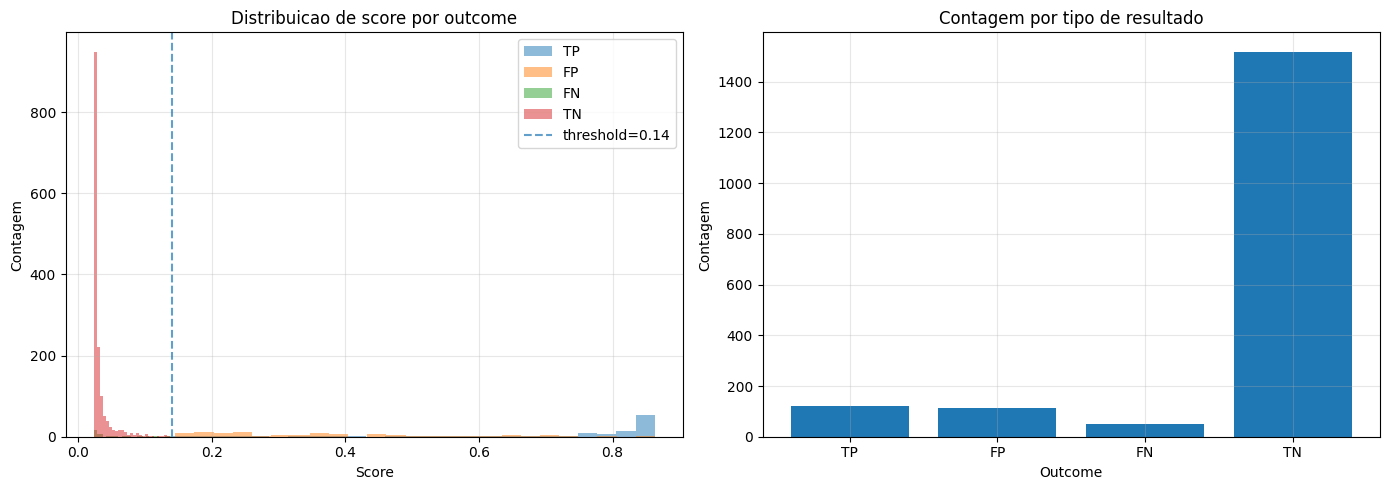


----------------------------------------------------------------------
Onde os erros se concentram?
----------------------------------------------------------------------

  Error rate por cat_region:
            error_rate    n
cat_region                 
oeste           0.1026  419
norte           0.0987  446
NaN             0.0960  125
sul             0.0848  389
leste           0.0689  421

  Error rate por cat_channel:
             error_rate    n
cat_channel                 
web              0.0986  588
app              0.0929  581
loja             0.0777  631

  Leitura rapida:
    - FP altos sugerem casos em que o modelo esta excessivamente confiante em positivos falsos.
    - FN sugerem positivos reais que o ranking deixou para tras.
    - Se FN se concentrarem em algum grupo, pode haver ponto cego do modelo.
    - Se FP se concentrarem em algum grupo, pode haver threshold agressivo demais para aquele perfil.


In [18]:
# ---------------------------------------------------------------------
# Bloco 14B — Error analysis de FP / FN
# ---------------------------------------------------------------------

print("=" * 70)
print("Error analysis — FP / FN")
print("=" * 70)

# ------------------------------------------------------------
# 1) Escolher score e threshold
# ------------------------------------------------------------
if "test_proba_calibrated" in globals():
    score_name = "proba_calibrated"
    score = np.asarray(test_proba_calibrated)
elif "test_proba_raw" in globals():
    score_name = "proba_raw"
    score = np.asarray(test_proba_raw)
else:
    raise ValueError("Nao encontrei 'test_proba_calibrated' nem 'test_proba_raw'.")

threshold_used = best_threshold if "best_threshold" in globals() else 0.50
pred = (score >= threshold_used).astype(int)

print(f"\n  Score usado     : {score_name}")
print(f"  Threshold usado : {threshold_used:.2f}")

# ------------------------------------------------------------
# 2) Base de erros em cima do df_test cru
# ------------------------------------------------------------
df_err = df_test.reset_index(drop=True).copy()
df_err["y_true"] = np.asarray(y_test)
df_err["score"] = score
df_err["y_pred"] = pred

def label_outcome(y_true, y_pred):
    if y_true == 1 and y_pred == 1:
        return "TP"
    elif y_true == 0 and y_pred == 0:
        return "TN"
    elif y_true == 0 and y_pred == 1:
        return "FP"
    elif y_true == 1 and y_pred == 0:
        return "FN"
    return "UNK"

df_err["outcome"] = [
    label_outcome(y_t, y_p)
    for y_t, y_p in zip(df_err["y_true"], df_err["y_pred"])
]

# ------------------------------------------------------------
# 3) Resumo geral
# ------------------------------------------------------------
outcome_counts = df_err["outcome"].value_counts().reindex(["TP", "FP", "FN", "TN"], fill_value=0)

print("\n  Contagem por tipo de resultado:")
for k, v in outcome_counts.items():
    print(f"    {k}: {v}")

print("\n  Taxas:")
print(f"    Precision = {precision_score(df_err['y_true'], df_err['y_pred'], zero_division=0):.4f}")
print(f"    Recall    = {recall_score(df_err['y_true'], df_err['y_pred'], zero_division=0):.4f}")
print(f"    F1        = {f1_score(df_err['y_true'], df_err['y_pred'], zero_division=0):.4f}")

# ------------------------------------------------------------
# 4) Perfil por categoricas
# ------------------------------------------------------------
cat_cols_probe = [c for c in ["cat_region", "cat_channel"] if c in df_err.columns]

for col in cat_cols_probe:
    print("\n" + "-" * 70)
    print(f"Perfil por {col}")
    print("-" * 70)

    aux = (
        df_err.groupby([col, "outcome"], dropna=False)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    for c in ["TP", "FP", "FN", "TN"]:
        if c not in aux.columns:
            aux[c] = 0

    aux["N"] = aux[["TP", "FP", "FN", "TN"]].sum(axis=1)
    aux["FP_rate_dentro_pred_positivo"] = aux["FP"] / (aux["FP"] + aux["TP"] + 1e-12)
    aux["FN_rate_dentro_real_positivo"] = aux["FN"] / (aux["FN"] + aux["TP"] + 1e-12)
    aux["erro_total_rate"] = (aux["FP"] + aux["FN"]) / aux["N"]

    aux = aux.sort_values("N", ascending=False)

    print(
        aux.to_string(
            index=False,
            formatters={
                "FP_rate_dentro_pred_positivo": lambda x: f"{x:.4f}",
                "FN_rate_dentro_real_positivo": lambda x: f"{x:.4f}",
                "erro_total_rate": lambda x: f"{x:.4f}",
            }
        )
    )

# ------------------------------------------------------------
# 5) Perfil numerico por outcome
# ------------------------------------------------------------
num_cols_probe = [c for c in ["feat_0", "feat_1", "feat_2", "feat_3", "feat_5"] if c in df_err.columns]

if num_cols_probe:
    print("\n" + "-" * 70)
    print("Perfil numerico por outcome (media)")
    print("-" * 70)

    num_profile_mean = df_err.groupby("outcome")[num_cols_probe].mean().T
    print(num_profile_mean.to_string(float_format=lambda x: f"{x:.4f}"))

    print("\n" + "-" * 70)
    print("Perfil numerico por outcome (mediana)")
    print("-" * 70)

    num_profile_median = df_err.groupby("outcome")[num_cols_probe].median().T
    print(num_profile_median.to_string(float_format=lambda x: f"{x:.4f}"))

# ------------------------------------------------------------
# 6) Erros mais perigosos
# ------------------------------------------------------------
fp_cases = df_err[df_err["outcome"] == "FP"].sort_values("score", ascending=False).copy()
fn_cases = df_err[df_err["outcome"] == "FN"].sort_values("score", ascending=True).copy()

print("\n" + "-" * 70)
print("Top 10 falsos positivos mais confiantes")
print("-" * 70)
if len(fp_cases) > 0:
    cols_show = [c for c in ["score", "cat_region", "cat_channel", "feat_0", "feat_1", "feat_2", "feat_3", "feat_5"] if c in fp_cases.columns]
    print(fp_cases[cols_show].head(10).to_string(index=False, float_format=lambda x: f"{x:.4f}"))
else:
    print("Nenhum falso positivo encontrado.")

print("\n" + "-" * 70)
print("Top 10 falsos negativos mais severos")
print("-" * 70)
if len(fn_cases) > 0:
    cols_show = [c for c in ["score", "cat_region", "cat_channel", "feat_0", "feat_1", "feat_2", "feat_3", "feat_5"] if c in fn_cases.columns]
    print(fn_cases[cols_show].head(10).to_string(index=False, float_format=lambda x: f"{x:.4f}"))
else:
    print("Nenhum falso negativo encontrado.")

# ------------------------------------------------------------
# 7) Distribuicao de score por outcome
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for outcome in ["TP", "FP", "FN", "TN"]:
    sub = df_err[df_err["outcome"] == outcome]
    if len(sub) > 0:
        axes[0].hist(sub["score"], bins=25, alpha=0.5, label=outcome)

axes[0].axvline(threshold_used, ls="--", alpha=0.7, label=f"threshold={threshold_used:.2f}")
axes[0].set_title("Distribuicao de score por outcome")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Contagem")
axes[0].legend()
axes[0].grid(alpha=0.3)

# barras de contagem
plot_counts = outcome_counts.reindex(["TP", "FP", "FN", "TN"])
axes[1].bar(plot_counts.index, plot_counts.values)
axes[1].set_title("Contagem por tipo de resultado")
axes[1].set_xlabel("Outcome")
axes[1].set_ylabel("Contagem")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

# ------------------------------------------------------------
# 8) Onde estao concentrados os erros?
# ------------------------------------------------------------
df_err["is_error"] = (df_err["y_true"] != df_err["y_pred"]).astype(int)

print("\n" + "-" * 70)
print("Onde os erros se concentram?")
print("-" * 70)

for col in cat_cols_probe:
    err_by_group = (
        df_err.groupby(col, dropna=False)["is_error"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "error_rate", "count": "n"})
        .sort_values("error_rate", ascending=False)
    )
    print(f"\n  Error rate por {col}:")
    print(err_by_group.to_string(float_format=lambda x: f"{x:.4f}"))

print("\n  Leitura rapida:")
print("    - FP altos sugerem casos em que o modelo esta excessivamente confiante em positivos falsos.")
print("    - FN sugerem positivos reais que o ranking deixou para tras.")
print("    - Se FN se concentrarem em algum grupo, pode haver ponto cego do modelo.")
print("    - Se FP se concentrarem em algum grupo, pode haver threshold agressivo demais para aquele perfil.")

Interpretabilidade orientada a conclusoes

  Calculando SHAP values (base para todas as analises)...


PermutationExplainer explainer: 601it [01:38,  5.56it/s]                                                               


  Explainer: Explainer generico (fallback)
  Amostras usadas: 600
  Valor base do modelo (log-odds): 0.0962

Pergunta 1 — Quais features realmente importam?


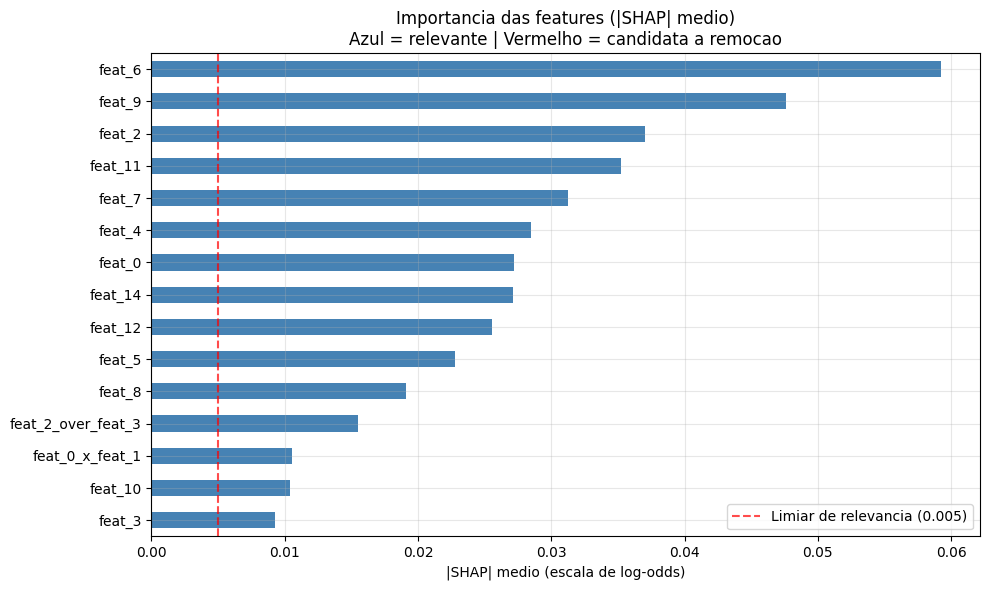


  CONCLUSAO — Pergunta 1:
    Features relevantes  : 17 (63% do total)
    Features irrelevantes: 10 (candidatas a remocao em proxima iteracao)
    Candidatas a remocao : ['cat_channel_loja', 'feat_2_is_missing', 'cat_region_sul', 'cat_region_norte', 'n_missing_total', 'feat_5_is_missing', 'cat_channel_web', 'feat_0_is_missing', 'cat_region_oeste', 'cat_region_is_missing']
    Acao sugerida: remover essas features e re-treinar o modelo.
    Espera-se impacto minimo na performance e ganho em
    simplicidade, interpretabilidade e velocidade de inferencia.

Pergunta 2 — As relacoes aprendidas fazem sentido?

  Direcao e monotonicidade das features relevantes:
           feature  |SHAP| medio  efeito medio         direcao  Spearman r        relacao         alerta
            feat_6        0.0592       -0.0052   ▼ reduz score      -0.059 nao-monotonica  ⚠️  verificar
            feat_9        0.0476        0.0031 ▲ aumenta score      -0.749     monotonica               
            feat_2

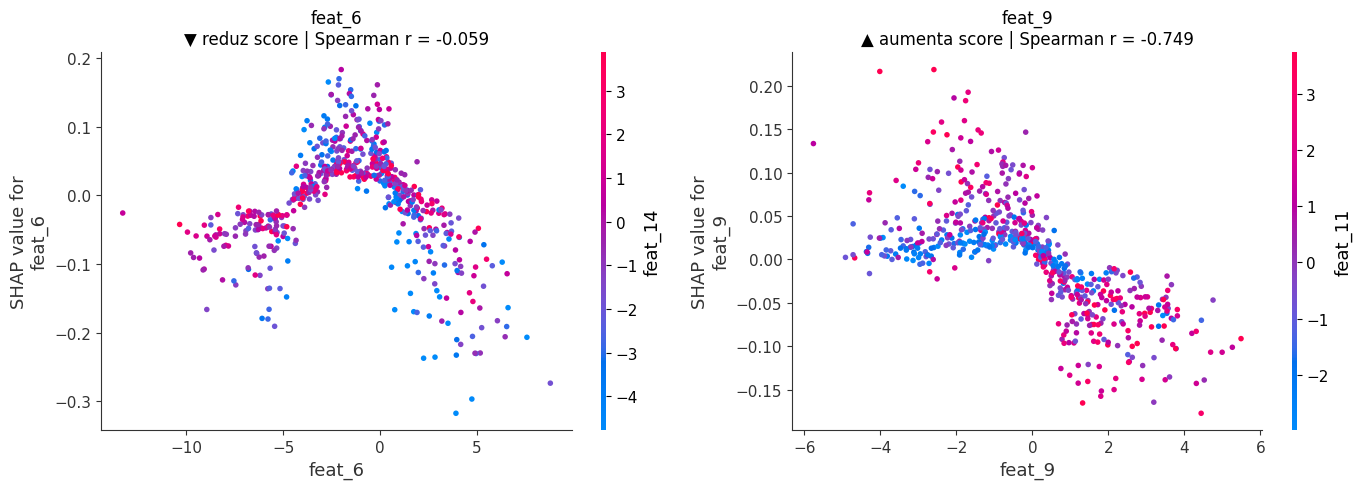


Pergunta 3 — O modelo e seguro para producao?

  Risco A — Dependencia de flags de ausencia:
    OK — Nenhuma flag de missing no top-10 de importancia.

  Risco B — Features correlacionadas dividindo importancia:
    ⚠️  2 par(es) de features relevantes com correlacao alta:
      - feat_6 <-> feat_7: Spearman r = 0.720
      - feat_2 <-> feat_2_over_feat_3: Spearman r = 0.835

  Risco C — Features sem contribuicao mensuravel:
    ⚠️  10 feature(s) com |SHAP| < 0.005:
      - cat_channel_loja: |SHAP| medio = 0.002630
      - feat_2_is_missing: |SHAP| medio = 0.002296
      - cat_region_sul: |SHAP| medio = 0.001682
      - cat_region_norte: |SHAP| medio = 0.001164
      - n_missing_total: |SHAP| medio = 0.000941
      - feat_5_is_missing: |SHAP| medio = 0.000905
      - cat_channel_web: |SHAP| medio = 0.000770
      - feat_0_is_missing: |SHAP| medio = 0.000704
      - cat_region_oeste: |SHAP| medio = 0.000592
      - cat_region_is_missing: |SHAP| medio = 0.000283

  CONCLUSAO — Pergunta

In [19]:
# ---------------------------------------------------------------------
# Bloco 15 — Interpretabilidade orientada a conclusoes
# ---------------------------------------------------------------------
#
# Este bloco responde quatro perguntas praticas sobre o modelo,
# em vez de apenas exibir graficos:
#
#   Pergunta 1 — Quais features realmente importam?
#   Identifica as features com contribuicao significativa e separa
#   automaticamente as relevantes das que podem ser descartadas
#   em uma proxima iteracao. Usa o |SHAP| medio como metrica de
#   importancia, que e mais confiavel que o gain nativo do XGBoost.
#
#   Pergunta 2 — As relacoes aprendidas fazem sentido?
#   Para cada feature relevante, verifica se o efeito e monotônico
#   (maior valor da feature sempre aumenta ou sempre diminui o score)
#   ou nao-monotonico (efeito muda de direcao dependendo do valor).
#   Relacoes inesperadas podem indicar overfitting ou data leakage.
#
#   Pergunta 3 — O modelo e seguro para producao?
#   Verifica automaticamente tres riscos comuns:
#     (a) se features de missing flag estao sendo usadas ativamente
#         (pode indicar que o padrao de ausencia e mais preditivo
#         que os valores em si, o que merece investigacao);
#     (b) se features correlacionadas estao dividindo o SHAP de
#         forma instavel (dificulta interpretacao e pode indicar
#         redundancia);
#     (c) se alguma feature tem contribuicao media proxima de zero
#         (candidata a remocao sem perda de performance).
#
#   Pergunta 4 — Por que o modelo errou nos casos mais criticos?
#   Analisa as contribuicoes SHAP dos erros mais graves (falsos
#   negativos com score muito baixo), identificando quais features
#   levaram o modelo a subestimar esses casos. E mais util do que
#   explicar previsoes corretas, pois direciona o trabalho de
#   melhoria do modelo.
#
# Ao final, um relatorio de conclusoes consolida os achados em um
# formato adequado para apresentacao a stakeholders.

print("=" * 70)
print("Interpretabilidade orientada a conclusoes")
print("=" * 70)

# Limiar de importancia: features com |SHAP| medio abaixo deste
# valor serao consideradas irrelevantes. O valor 0.005 corresponde
# a aproximadamente meia unidade de log-odds em media, o que e
# uma contribuicao muito pequena para a previsao final.
SHAP_IMPORTANCE_THRESHOLD = 0.005

# Limiar de correlacao para detectar features redundantes.
# Pares com correlacao de Spearman acima deste valor serao
# sinalizados para investigacao.
CORRELATION_THRESHOLD = 0.7

# Numero de observacoes amostradas para calculo SHAP.
# 600 observacoes oferecem boa representatividade mantendo
# tempo de calculo razoavel.
N_SHAP_SAMPLES = min(600, len(X_test))

# Numero de features exibidas nos graficos.
TOP_N_FEATURES = 15

# ----------------------------------------------------------------
# Preparacao: calcula SHAP values uma unica vez e reutiliza
# em todas as secoes, evitando reprocessamento desnecessario.
# ----------------------------------------------------------------
print("\n  Calculando SHAP values (base para todas as analises)...")

X_shap = X_test.sample(N_SHAP_SAMPLES, random_state=SEED).reset_index(drop=True)

# TreeExplainer e exato e rapido para modelos baseados em arvores.
# O fallback para o Explainer generico garante compatibilidade com
# diferentes versoes do par shap/xgboost.
try:
    explainer = shap.TreeExplainer(final_model)
    shap_exp = explainer(X_shap)
    explainer_type = "TreeExplainer (exato)"
except Exception:
    background = X_train.sample(100, random_state=SEED)
    def _predict(X):
        return final_model.predict(xgb.DMatrix(X, feature_names=feature_cols))
    explainer = shap.Explainer(_predict, background, feature_names=feature_cols)
    shap_exp = explainer(X_shap)
    explainer_type = "Explainer generico (fallback)"

shap_vals = shap_exp.values                        # shape: (N_SHAP_SAMPLES, n_features)
base_value = float(np.mean(shap_exp.base_values))  # previsao media do modelo (log-odds)

# Importancia por feature: media do valor absoluto dos SHAP values.
# Esta metrica indica o impacto medio de cada feature nas previsoes,
# independentemente da direcao (positiva ou negativa).
shap_importance = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=X_shap.columns,
).sort_values(ascending=False)

# Efeito medio por feature: media (sem valor absoluto) dos SHAP
# values. Indica a direcao predominante do efeito de cada feature:
# positivo significa que a feature, em media, aumenta o score;
# negativo significa que reduz.
shap_mean_effect = pd.Series(
    shap_vals.mean(axis=0),
    index=X_shap.columns,
)

print(f"  Explainer: {explainer_type}")
print(f"  Amostras usadas: {N_SHAP_SAMPLES}")
print(f"  Valor base do modelo (log-odds): {base_value:.4f}")


# ================================================================
# PERGUNTA 1 — Quais features realmente importam?
# ================================================================
print("\n" + "=" * 70)
print("Pergunta 1 — Quais features realmente importam?")
print("=" * 70)
#
# Dividimos as features em tres grupos:
#   - Relevantes: |SHAP| medio acima do limiar. Sao os principais
#     drivers do modelo e merecem atencao do negocio.
#   - Marginais: |SHAP| medio muito proximo do limiar. Contribuem
#     pouco e sao candidatas a remocao em proxima iteracao.
#   - Irrelevantes: |SHAP| medio abaixo do limiar. Nao contribuem
#     de forma mensuravel e podem ser removidas sem perda de
#     performance, reduzindo a complexidade do modelo.

features_relevantes = shap_importance[shap_importance >= SHAP_IMPORTANCE_THRESHOLD]
features_irrelevantes = shap_importance[shap_importance < SHAP_IMPORTANCE_THRESHOLD]

# Grafico: barra horizontal do |SHAP| medio por feature.
# A linha vertical vermelha indica o limiar de relevancia.
# Features a esquerda da linha sao candidatas a descarte.
fig, ax = plt.subplots(figsize=(10, max(5, TOP_N_FEATURES * 0.4)))
top_imp = shap_importance.head(TOP_N_FEATURES).sort_values(ascending=True)
colors = [
    "steelblue" if v >= SHAP_IMPORTANCE_THRESHOLD else "lightcoral"
    for v in top_imp.values
]
top_imp.plot.barh(ax=ax, color=colors)
ax.axvline(SHAP_IMPORTANCE_THRESHOLD, color="red", ls="--", alpha=0.7,
           label=f"Limiar de relevancia ({SHAP_IMPORTANCE_THRESHOLD})")
ax.set_title(
    f"Importancia das features (|SHAP| medio)\n"
    f"Azul = relevante | Vermelho = candidata a remocao"
)
ax.set_xlabel("|SHAP| medio (escala de log-odds)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

# Conclusao automatica da Pergunta 1
print(f"\n  CONCLUSAO — Pergunta 1:")
print(f"    Features relevantes  : {len(features_relevantes)} "
      f"({len(features_relevantes)/len(shap_importance):.0%} do total)")
print(f"    Features irrelevantes: {len(features_irrelevantes)} "
      f"(candidatas a remocao em proxima iteracao)")
if len(features_irrelevantes) > 0:
    print(f"    Candidatas a remocao : {list(features_irrelevantes.index)}")
    print(f"    Acao sugerida: remover essas features e re-treinar o modelo.")
    print(f"    Espera-se impacto minimo na performance e ganho em")
    print(f"    simplicidade, interpretabilidade e velocidade de inferencia.")
else:
    print(f"    Todas as features contribuem acima do limiar.")


# ================================================================
# PERGUNTA 2 — As relacoes aprendidas fazem sentido?
# ================================================================
print("\n" + "=" * 70)
print("Pergunta 2 — As relacoes aprendidas fazem sentido?")
print("=" * 70)
#
# Para cada feature relevante, calculamos:
#   - Direcao predominante: o sinal do efeito medio (positivo ou
#     negativo). Indica se a feature, em media, aumenta ou reduz
#     o score previsto.
#   - Monotonicidade: correlacao de Spearman entre o valor da
#     feature e seu SHAP value. Correlacao alta (|r| > 0.5)
#     indica relacao monotonica consistente. Correlacao baixa
#     indica efeito nao-monotônico (o impacto da feature muda
#     de direcao dependendo do valor que ela assume).
#
# Relacoes nao-monotonicas sao legitimas (arvores capturam esses
# padroes naturalmente), mas merecem verificacao no dominio do
# problema: o negocio consegue explicar por que o efeito muda?

# Seleciona apenas as features relevantes e numericas para esta analise
num_feat_relevantes = [
    f for f in features_relevantes.index
    if f in X_shap.columns
    and pd.api.types.is_numeric_dtype(X_shap[f])
    and not f.endswith("_is_missing")
][:TOP_N_FEATURES]

direction_rows = []
for feat in num_feat_relevantes:
    feat_vals = X_shap[feat].values
    feat_shap = shap_vals[:, X_shap.columns.get_loc(feat)]

    # Correlacao de Spearman entre valor da feature e seu SHAP value.
    # Usamos Spearman (e nao Pearson) pois o efeito pode ser nao-linear.
    from scipy.stats import spearmanr
    corr, pval = spearmanr(feat_vals, feat_shap, nan_policy="omit")

    efeito_medio = shap_mean_effect[feat]
    direcao = "▲ aumenta score" if efeito_medio > 0 else "▼ reduz score"
    monotonicidade = "monotonica" if abs(corr) >= 0.5 else "nao-monotonica"
    alerta = " ⚠️  verificar" if abs(corr) < 0.3 else ""

    direction_rows.append({
        "feature": feat,
        "|SHAP| medio": round(shap_importance[feat], 4),
        "efeito medio": round(efeito_medio, 4),
        "direcao": direcao,
        "Spearman r": round(corr, 3),
        "relacao": monotonicidade,
        "alerta": alerta,
    })

direction_df = pd.DataFrame(direction_rows).sort_values("|SHAP| medio", ascending=False)

print("\n  Direcao e monotonicidade das features relevantes:")
print(direction_df.to_string(index=False))

# Conclusao automatica da Pergunta 2
features_suspeitas = direction_df[direction_df["alerta"] != ""]
print(f"\n  CONCLUSAO — Pergunta 2:")
if len(features_suspeitas) == 0:
    print(f"    Todas as features relevantes tem relacao consistente com o score.")
    print(f"    Nenhuma relacao inesperada detectada automaticamente.")
else:
    print(f"    {len(features_suspeitas)} feature(s) com efeito muito inconsistente (|r| < 0.3):")
    for _, row in features_suspeitas.iterrows():
        print(f"      - {row['feature']}: Spearman r = {row['Spearman r']:.3f}")
    print(f"    Acao sugerida: inspecionar o dependence plot dessas features")
    print(f"    e verificar com especialistas do dominio se o comportamento")
    print(f"    detectado faz sentido ou pode indicar overfitting.")

# Dependence plot das 2 features mais importantes para inspecao visual
print(f"\n  Dependence plots das 2 features mais importantes:")
top2 = [row["feature"] for _, row in direction_df.head(2).iterrows()]
fig, axes = plt.subplots(1, len(top2), figsize=(7 * len(top2), 5))
if len(top2) == 1:
    axes = [axes]
for ax, feat in zip(axes, top2):
    shap.dependence_plot(feat, shap_vals, X_shap, ax=ax, show=False)
    efeito = direction_df.loc[direction_df["feature"] == feat, "direcao"].values[0]
    r_val = direction_df.loc[direction_df["feature"] == feat, "Spearman r"].values[0]
    ax.set_title(f"{feat}\n{efeito} | Spearman r = {r_val:.3f}")
plt.tight_layout()
plt.show()
plt.close()


# ================================================================
# PERGUNTA 3 — O modelo e seguro para producao?
# ================================================================
print("\n" + "=" * 70)
print("Pergunta 3 — O modelo e seguro para producao?")
print("=" * 70)
#
# Verificamos tres riscos automaticamente:
#
#   Risco A — Dependencia excessiva de flags de ausencia:
#   Se as features "_is_missing" aparecem entre as mais importantes,
#   o modelo esta usando o padrao de ausencia como sinal preditivo.
#   Isso e aceitavel se a ausencia for informativa por razao de
#   negocio (ex: cliente que nao informa renda tem perfil diferente).
#   Mas pode indicar que o preenchimento dos dados em producao difere
#   do treino, o que degradaria a performance.
#
#   Risco B — Features redundantes dividindo importancia:
#   Features altamente correlacionadas entre si dividem o SHAP de
#   forma instavel. O modelo pode depender de uma ou outra
#   dependendo do fold de treino, tornando a interpretacao fragil.
#
#   Risco C — Features com contribuicao quase nula:
#   Ja identificadas na Pergunta 1; confirmadas aqui como risco
#   de manutencao (features inuteis aumentam a superficie de falha
#   em producao sem agregar valor preditivo).

safety_issues = []

# --- Risco A: flags de missing entre as mais importantes ---
missing_flags_in_top = [
    f for f in features_relevantes.head(10).index
    if f.endswith("_is_missing")
]
print(f"\n  Risco A — Dependencia de flags de ausencia:")
if missing_flags_in_top:
    print(f"    ⚠️  {len(missing_flags_in_top)} flag(s) de missing no top-10 de importancia:")
    for f in missing_flags_in_top:
        print(f"      - {f}: |SHAP| medio = {shap_importance[f]:.4f}")
    safety_issues.append(
        f"Flags de missing relevantes: {missing_flags_in_top}. "
        f"Verificar se o padrao de ausencia em producao sera identico ao treino."
    )
else:
    print(f"    OK — Nenhuma flag de missing no top-10 de importancia.")

# --- Risco B: features correlacionadas entre as relevantes ---
print(f"\n  Risco B — Features correlacionadas dividindo importancia:")
relevant_num = [
    f for f in features_relevantes.index
    if f in X_shap.columns and pd.api.types.is_numeric_dtype(X_shap[f])
]
if len(relevant_num) >= 2:
    corr_matrix = X_shap[relevant_num].corr(method="spearman").abs()
    high_corr_pairs = []
    for i in range(len(relevant_num)):
        for j in range(i + 1, len(relevant_num)):
            r = corr_matrix.iloc[i, j]
            if r >= CORRELATION_THRESHOLD:
                high_corr_pairs.append((relevant_num[i], relevant_num[j], r))

    if high_corr_pairs:
        print(f"    ⚠️  {len(high_corr_pairs)} par(es) de features relevantes com correlacao alta:")
        for f1, f2, r in high_corr_pairs:
            print(f"      - {f1} <-> {f2}: Spearman r = {r:.3f}")
        safety_issues.append(
            f"{len(high_corr_pairs)} par(es) de features correlacionadas. "
            f"Considerar remover a menos importante de cada par."
        )
    else:
        print(f"    OK — Nenhum par relevante com correlacao >= {CORRELATION_THRESHOLD}.")
else:
    print(f"    Poucos features numericos relevantes para verificar correlacao.")

# --- Risco C: features irrelevantes em producao ---
print(f"\n  Risco C — Features sem contribuicao mensuravel:")
if len(features_irrelevantes) > 0:
    print(f"    ⚠️  {len(features_irrelevantes)} feature(s) com |SHAP| < {SHAP_IMPORTANCE_THRESHOLD}:")
    for f, v in features_irrelevantes.items():
        print(f"      - {f}: |SHAP| medio = {v:.6f}")
    safety_issues.append(
        f"{len(features_irrelevantes)} feature(s) sem contribuicao mensuravel. "
        f"Remover para simplificar o pipeline de producao."
    )
else:
    print(f"    OK — Todas as features contribuem acima do limiar.")

# Conclusao automatica da Pergunta 3
print(f"\n  CONCLUSAO — Pergunta 3:")
if len(safety_issues) == 0:
    print(f"    Nenhum risco detectado automaticamente.")
    print(f"    O modelo parece seguro para producao sob os criterios verificados.")
else:
    print(f"    {len(safety_issues)} item(ns) para revisao antes de ir a producao:")
    for i, issue in enumerate(safety_issues, 1):
        print(f"    {i}. {issue}")


# ================================================================
# PERGUNTA 4 — Por que o modelo errou nos casos mais criticos?
# ================================================================
print("\n" + "=" * 70)
print("Pergunta 4 — Por que o modelo errou nos casos mais criticos?")
print("=" * 70)
#
# Focamos nos falsos negativos mais severos: observacoes reais
# positivas (y_true = 1) para as quais o modelo atribuiu score
# muito baixo. Sao os erros mais graves em problemas onde deixar
# passar um positivo e caro (fraude, diagnostico, churn).
#
# Para cada um desses casos, calculamos os SHAP values e
# identificamos quais features mais contribuiram para o score
# baixo (ou seja, quais features "enganaram" o modelo).
# Padroes recorrentes nessas contribuicoes indicam onde o modelo
# tem pontos cegos sistematicos.

# Identifica os falsos negativos mais severos no subconjunto SHAP
y_shap = y_test.iloc[X_test.sample(N_SHAP_SAMPLES, random_state=SEED).index].reset_index(drop=True)

# Calcula o score do modelo para o subconjunto SHAP
dshap = xgb.DMatrix(X_shap, feature_names=feature_cols)
scores_shap = final_model.predict(dshap, iteration_range=(0, best_iter_final))

# Filtra falsos negativos: y_true = 1 e score abaixo do threshold
threshold_used = best_threshold if "best_threshold" in globals() else 0.50
fn_mask = (y_shap.values == 1) & (scores_shap < threshold_used)
fn_indices = np.where(fn_mask)[0]

print(f"\n  Falsos negativos no subconjunto SHAP: {len(fn_indices)}")
print(f"  (positivos reais com score < {threshold_used:.2f})")

if len(fn_indices) > 0:
    # Ordena pelos mais severos (menor score entre os FN)
    fn_scores = scores_shap[fn_indices]
    fn_order = fn_indices[np.argsort(fn_scores)]
    top_fn = fn_order[:min(5, len(fn_order))]

    # Calcula a contribuicao media de cada feature nos FN mais severos
    fn_shap_matrix = shap_vals[top_fn, :]
    fn_mean_contrib = pd.Series(
        fn_shap_matrix.mean(axis=0),
        index=X_shap.columns,
    ).sort_values(ascending=True)  # mais negativos primeiro

    # Features que mais puxaram o score para baixo nesses casos
    top_neg_drivers = fn_mean_contrib.head(8)
    top_pos_drivers = fn_mean_contrib.tail(5).sort_values(ascending=False)

    print(f"\n  Features que mais reduziram o score nos FN mais severos:")
    print(f"  (contribuicao SHAP media negativa — puxaram score para baixo)")
    for feat, val in top_neg_drivers.items():
        feat_val_medio = X_shap.iloc[top_fn][feat].mean()
        print(f"    {feat:30s}: SHAP medio = {val:+.4f} | valor medio = {feat_val_medio:.4f}")

    print(f"\n  Features que tentaram aumentar o score nesses casos:")
    print(f"  (contribuicao SHAP media positiva — mas nao foram suficientes)")
    for feat, val in top_pos_drivers.items():
        feat_val_medio = X_shap.iloc[top_fn][feat].mean()
        print(f"    {feat:30s}: SHAP medio = {val:+.4f} | valor medio = {feat_val_medio:.4f}")

    # Conclusao automatica da Pergunta 4
    print(f"\n  CONCLUSAO — Pergunta 4:")
    print(f"    O principal driver dos falsos negativos mais severos e:")
    print(f"    '{top_neg_drivers.index[0]}' (SHAP medio = {top_neg_drivers.iloc[0]:+.4f})")
    print(f"    Acao sugerida: investigar se essa feature captura adequadamente")
    print(f"    o comportamento dos positivos mais dificeis de detectar.")
    print(f"    Se possivel, criar features derivadas que complementem")
    print(f"    o sinal de '{top_neg_drivers.index[0]}' nesses casos.")
else:
    print(f"  Nenhum falso negativo encontrado no subconjunto SHAP.")
    print(f"  Tente reduzir o threshold ou aumentar N_SHAP_SAMPLES.")


# ================================================================
# RELATORIO FINAL DE INTERPRETABILIDADE
# ================================================================
print("\n" + "=" * 70)
print("Relatorio final de interpretabilidade")
print("=" * 70)

print(f"""
  MODELO: XGBoost com {len(feature_cols)} features de entrada
  EXPLAINER: {explainer_type}
  AMOSTRAS ANALISADAS: {N_SHAP_SAMPLES}

  [P1] IMPORTANCIA:
       {len(features_relevantes)} features relevantes | {len(features_irrelevantes)} candidatas a remocao
       Top-3: {', '.join(shap_importance.head(3).index.tolist())}

  [P2] RELACOES:
       {len(features_suspeitas)} feature(s) com efeito inconsistente para verificacao
       {len(direction_df) - len(features_suspeitas)} feature(s) com relacao consistente

  [P3] RISCOS DE PRODUCAO:
       {len(safety_issues)} item(ns) para revisao
       {"Nenhum risco detectado." if not safety_issues else chr(10).join(f"       - {s}" for s in safety_issues)}

  [P4] ERROS CRITICOS:
       {len(fn_indices)} FN no subconjunto SHAP
       {"Principal driver dos FN: " + top_neg_drivers.index[0] if len(fn_indices) > 0 else "Nenhum FN encontrado."}

  LEMBRE-SE: SHAP mede associacao, nao causalidade.
  Os achados devem ser validados com especialistas do dominio.
""")

(Extensao) Robustez: degradacao controlada

  AUC base (sem ruido): 0.8907
  Limiares: Robusto < 0.03 | Sensivel < 0.1 | Fragil >= 0.1

Analise 1 — Ruido numerico global (todas as features numericas)
  sigma x 0.05 | AUC = 0.8899 +/- 0.0017 | delta = -0.0008 | Robusto
  sigma x 0.10 | AUC = 0.8864 +/- 0.0039 | delta = -0.0043 | Robusto
  sigma x 0.25 | AUC = 0.8772 +/- 0.0065 | delta = -0.0135 | Robusto
  sigma x 0.50 | AUC = 0.8364 +/- 0.0105 | delta = -0.0543 | Sensivel

Analise 2 — Ruido categorico (por coluna, independentemente)

  Testando coluna: cat_region

  Testando coluna: cat_channel

  Testando coluna: cat_region
    ruido 5% | AUC = 0.8908 +/- 0.0001 | delta = +0.0001 | Robusto
    ruido 10% | AUC = 0.8907 +/- 0.0002 | delta = -0.0000 | Robusto
    ruido 20% | AUC = 0.8907 +/- 0.0003 | delta = -0.0000 | Robusto

  Testando coluna: cat_channel
    ruido 5% | AUC = 0.8907 +/- 0.0003 | delta = -0.0000 | Robusto
    ruido 10% | AUC = 0.8906 +/- 0.0004 | delta = -0.0001 | Robus

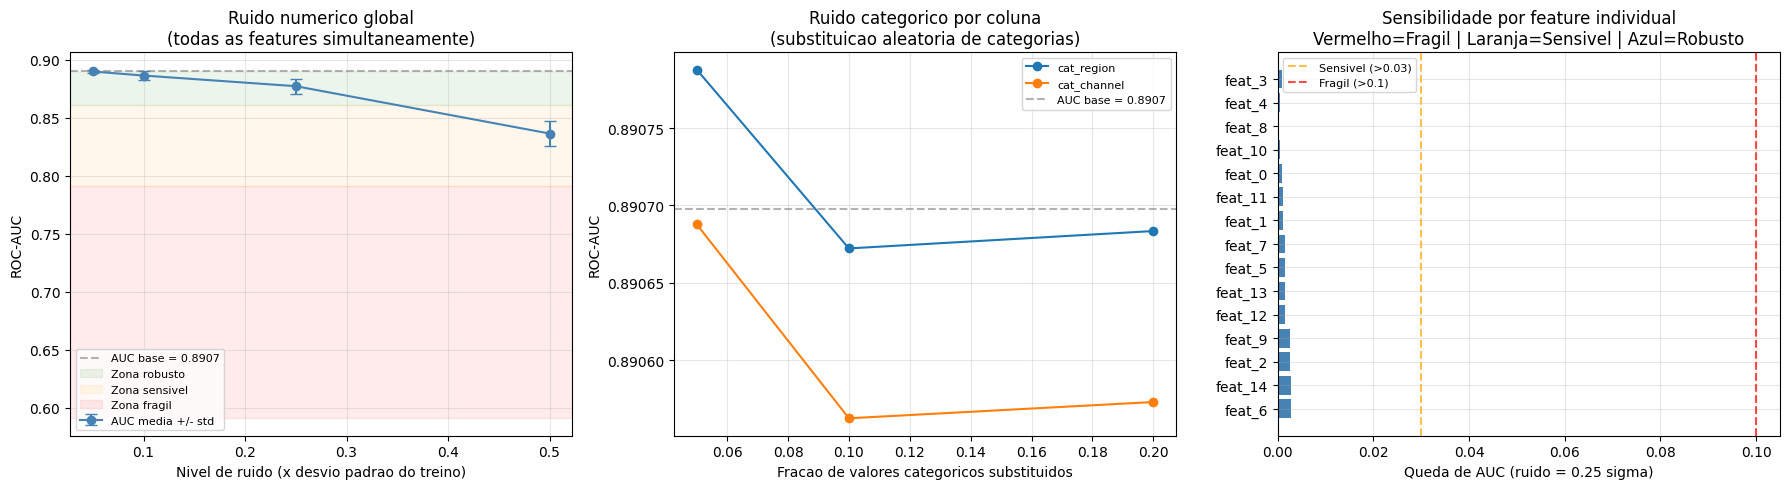


Relatorio de robustez

  [A1] Ruido numerico global:
       Pior cenario testado (sigma x 0.50): AUC = 0.8364 | delta = -0.0543 | Sensivel

  [A2] Ruido categorico:
       cat_region: pior caso (10% substituido) -> delta = -0.0000 | Robusto
       cat_channel: pior caso (10% substituido) -> delta = -0.0001 | Robusto

  [A3] Features criticas (Sensivel ou Fragil com ruido 0.25 sigma):
       Nenhuma feature individualmente critica detectada.
       O modelo e robusto a perturbacoes individuais de 0.25 sigma.


In [20]:
# ---------------------------------------------------------------------
# Bloco 16 — (Extensao) Robustez: degradacao controlada
# ---------------------------------------------------------------------
#
# Em producao, os dados de entrada podem ser mais ruidosos do que os
# dados de treino. Um modelo robusto deve degradar gradualmente
# conforme o ruido aumenta. Se a performance cai abruptamente com
# niveis baixos de ruido, o modelo e fragil e provavelmente nao
# se comportara bem em producao.
#
# Este bloco realiza tres analises complementares de robustez:
#
#   Analise 1 — Ruido numerico global:
#   Adiciona ruido gaussiano de intensidade crescente a todas as
#   features numericas simultaneamente e mede a degradacao da AUC.
#   Simula cenarios como erro sistematico de sensor, mudanca de
#   escala de medicao ou corrupcao de dados na ingestao.
#   Para cada nivel de ruido, o teste e repetido N_REPS vezes com
#   sementes diferentes para obter media e desvio padrao estaveis.
#
#   Analise 2 — Ruido categorico:
#   Substitui aleatoriamente uma fracao dos valores categoricos por
#   outras categorias validas. Simula erros de digitacao, mudancas
#   de codificacao entre sistemas ou inconsistencias de integracao.
#   Testa cada coluna categorica de forma independente para
#   identificar quais sao mais criticas para a performance.
#
#   Analise 3 — Sensibilidade por feature individual:
#   Adiciona ruido a uma feature de cada vez (mantendo as demais
#   intactas) e mede a queda de AUC causada por aquela feature
#   especifica. Identifica os pontos mais frageis do modelo e
#   orienta a priorizacao do monitoramento de qualidade de dados
#   em producao. Features com alta sensibilidade individual merecem
#   alertas dedicados no pipeline de ingestao.
#
# Criterio de classificacao de robustez (usado nas tres analises):
#   - Robusto  : queda de AUC < 0.03 (degradacao aceitavel)
#   - Sensivel : queda de AUC entre 0.03 e 0.10 (requer atencao)
#   - Fragil   : queda de AUC >= 0.10 (risco alto para producao)

print("=" * 70)
print("(Extensao) Robustez: degradacao controlada")
print("=" * 70)

# --- Parametros globais ---
# Centralizar esses valores facilita ajustar o experimento sem
# alterar a logica do codigo.

# Niveis de ruido numerico a testar, expressos como multiplos do
# desvio padrao de cada feature no treino.
NOISE_LEVELS = [0.05, 0.10, 0.25, 0.50]

# Fracoes de substituicao para o ruido categorico.
# 0.05 significa que 5% dos valores serao substituidos aleatoriamente.
CAT_NOISE_LEVELS = [0.05, 0.10, 0.20]

# Numero de repeticoes por nivel de ruido. Mais repeticoes dao
# estimativas mais estaveis de media e desvio padrao, ao custo de
# maior tempo de execucao.
N_REPS = 10

# Nivel de ruido usado na analise de sensibilidade por feature.
# Usamos um valor moderado (0.25) para detectar features sensiveis
# sem precisar testar multiplos niveis por feature.
SENSITIVITY_NOISE_LEVEL = 0.25

# Numero de repeticoes na analise por feature. Menos que N_REPS
# porque essa analise e executada uma vez por feature — com muitas
# features, o tempo total seria proibitivo.
N_REPS_SENSITIVITY = 5

# Limiares de classificacao de robustez
ROBUST_THRESHOLD  = 0.03   # queda de AUC considerada aceitavel
FRAGILE_THRESHOLD = 0.10   # queda de AUC considerada critica


def classify_robustness(delta: float) -> str:
    '''Classifica a degradacao de AUC em tres niveis de risco.

    Recebe o delta (diferenca entre AUC com ruido e AUC base,
    sempre negativo ou zero) e retorna uma string descritiva.
    Usa valor absoluto para tratar tanto quedas quanto ganhos
    espurios de forma simetrica.
    '''
    if abs(delta) < ROBUST_THRESHOLD:
        return "Robusto"
    elif abs(delta) < FRAGILE_THRESHOLD:
        return "Sensivel"
    else:
        return "Fragil"


def add_numeric_noise(df_in: pd.DataFrame,
                      cols: list,
                      noise_level: float,
                      scale: pd.Series,
                      rng: np.random.Generator) -> pd.DataFrame:
    '''Adiciona ruido gaussiano proporcional ao desvio padrao do treino.

    Para cada coluna em cols, adiciona ruido com desvio padrao igual
    a noise_level * scale[col]. Isso garante que o ruido e relativo
    a magnitude de cada feature, evitando que features de grande
    escala sejam pouco afetadas enquanto features de pequena escala
    sejam destruidas.

    Parametros:
      df_in      : DataFrame original (nao modificado in-place)
      cols       : lista de colunas que receberao ruido
      noise_level: multiplo do desvio padrao a usar como magnitude
      scale      : Series com o desvio padrao de cada coluna no treino
      rng        : gerador de numeros aleatorios (para reproducibilidade)
    '''
    df_out = df_in.copy()
    for col in cols:
        sigma = float(scale.get(col, 1.0))
        df_out[col] = df_out[col] + rng.normal(
            loc=0.0,
            scale=noise_level * sigma,
            size=len(df_out),
        )
    return df_out


def add_categorical_noise(df_in: pd.DataFrame,
                          col: str,
                          noise_frac: float,
                          rng: np.random.Generator,
                          known_categories: dict = None) -> pd.DataFrame:  # ← novo parametro
    '''Substitui aleatoriamente uma fracao dos valores categoricos.

    Para simular erros de digitacao, inconsistencias de codificacao
    ou mudancas de categoria entre sistemas, substitui noise_frac
    das observacoes por uma categoria valida diferente da original.
    Valores ausentes nao sao modificados (a mascara exclui NaNs).

    Parametros:
      df_in            : DataFrame original (nao modificado in-place)
      col              : nome da coluna categorica a perturbar
      noise_frac       : fracao de linhas a substituir (ex: 0.10 = 10%)
      rng              : gerador de numeros aleatorios
      known_categories : dict mapeando nome da coluna para lista de
                         categorias validas vistas no treino. Garante
                         que a simulacao de ruido usa apenas categorias
                         que o encoder conhece, replicando fielmente
                         o comportamento em producao. Se None, usa as
                         categorias presentes em df_in (menos rigoroso).
    '''
    df_out = df_in.copy()

    # Prioriza categorias do treino para simular producao corretamente.
    # Usar categorias do teste poderia incluir valores que o encoder
    # nunca viu no treino, distorcendo a simulacao.
    if known_categories is not None and col in known_categories:
        categories = known_categories[col]
    else:
        categories = df_out[col].dropna().unique().tolist()

    # Se ha apenas uma categoria, nao ha substituicao possivel
    if len(categories) < 2:
        return df_out

    # Seleciona as linhas a perturbar (excluindo NaNs)
    not_null_mask = df_out[col].notna()
    perturb_mask  = not_null_mask & (rng.random(len(df_out)) < noise_frac)

    # Para cada linha selecionada, escolhe uma categoria diferente
    # da original. A exclusao da categoria original evita que a
    # "perturbacao" mantenha o mesmo valor.
    original_vals = df_out.loc[perturb_mask, col].values
    new_vals = []
    for orig in original_vals:
        alternativas = [c for c in categories if c != orig]
        new_vals.append(rng.choice(alternativas))

    df_out.loc[perturb_mask, col] = new_vals
    return df_out


def eval_with_noise(df_noisy: pd.DataFrame) -> float:
    '''Aplica o pipeline completo e retorna a AUC no teste ruidoso.

    Reprocessa o DataFrame ruidoso pelo mesmo preprocessador do
    treino global (sem re-ajustar estatisticas), converte para
    DMatrix e gera previsoes com o modelo final.
    '''
    X_noisy, _ = transform_with_preprocessor(
        df_noisy, preprocessor, return_target=True
    )
    d_noisy = xgb.DMatrix(X_noisy, label=y_test, feature_names=feature_cols)
    p_noisy = final_model.predict(d_noisy, iteration_range=(0, best_iter_final))
    return roc_auc_score(y_test, p_noisy)


# --- Preparacao: estatisticas e AUC base ---
# O desvio padrao e calculado no treino original (sem preprocessamento)
# para dimensionar o ruido na escala das features brutas, que e onde
# o ruido e inserido antes do preprocessamento.
noise_cols      = raw_num_cols.copy()
train_noise_scale = df_train[noise_cols].std().replace(0, 1.0)

# AUC de referencia: modelo no teste sem nenhum ruido
auc_clean = eval_with_noise(df_test)

print(f"\n  AUC base (sem ruido): {auc_clean:.4f}")
print(f"  Limiares: Robusto < {ROBUST_THRESHOLD} | "
      f"Sensivel < {FRAGILE_THRESHOLD} | Fragil >= {FRAGILE_THRESHOLD}")


# ================================================================
# ANALISE 1 — Ruido numerico global
# ================================================================
print("\n" + "=" * 70)
print("Analise 1 — Ruido numerico global (todas as features numericas)")
print("=" * 70)
#
# Todas as features numericas recebem ruido simultaneamente.
# Este e o cenario mais pessimista: todos os campos estao ruidosos
# ao mesmo tempo. A degradacao aqui representa um limite superior
# do impacto do ruido numerico no modelo.

robust_rows = []

for noise_level in NOISE_LEVELS:
    auc_reps = []

    for rep in range(N_REPS):
        # Seed diferente por repeticao, mas reprodutivel
        rng_rep = np.random.default_rng(SEED + rep)
        df_noisy = add_numeric_noise(
            df_test, noise_cols, noise_level, train_noise_scale, rng_rep
        )
        auc_reps.append(eval_with_noise(df_noisy))

    auc_mean  = float(np.mean(auc_reps))
    auc_std   = float(np.std(auc_reps))
    delta     = auc_mean - auc_clean
    avaliacao = classify_robustness(delta)

    robust_rows.append({
        "noise_level"  : noise_level,
        "auc_mean"     : auc_mean,
        "auc_std"      : auc_std,
        "delta_vs_clean": delta,
        "avaliacao"    : avaliacao,
    })

    print(f"  sigma x {noise_level:.2f} | AUC = {auc_mean:.4f} +/- {auc_std:.4f} "
          f"| delta = {delta:+.4f} | {avaliacao}")

robust_df = pd.DataFrame(robust_rows)


# ================================================================
# ANALISE 2 — Ruido categorico por coluna
# ================================================================
print("\n" + "=" * 70)
print("Analise 2 — Ruido categorico (por coluna, independentemente)")
print("=" * 70)
#
# Cada coluna categorica e perturbada de forma independente.
# Isso permite identificar quais categoricas sao mais criticas
# para a performance do modelo quando ha erros de codificacao.

# Deve usar df_train (antes do preprocessamento) para capturar
# exatamente o que o OneHotEncoder viu durante o ajuste.
train_categories = {
    col: df_train[col].dropna().unique().tolist()
    for col in low_card_cats
}

for col in low_card_cats:
    print(f"\n  Testando coluna: {col}")

cat_robust_rows = []

for col in low_card_cats:
    print(f"\n  Testando coluna: {col}")

    for noise_frac in CAT_NOISE_LEVELS:
        auc_reps = []

        for rep in range(N_REPS):
            rng_rep = np.random.default_rng(SEED + rep)
            df_noisy = add_categorical_noise(df_test, col, noise_frac, rng_rep,
                                 known_categories=train_categories)
            auc_reps.append(eval_with_noise(df_noisy))

        auc_mean  = float(np.mean(auc_reps))
        auc_std   = float(np.std(auc_reps))
        delta     = auc_mean - auc_clean
        avaliacao = classify_robustness(delta)

        cat_robust_rows.append({
            "coluna"       : col,
            "noise_frac"   : noise_frac,
            "auc_mean"     : auc_mean,
            "auc_std"      : auc_std,
            "delta_vs_clean": delta,
            "avaliacao"    : avaliacao,
        })

        print(f"    ruido {noise_frac:.0%} | AUC = {auc_mean:.4f} +/- {auc_std:.4f} "
              f"| delta = {delta:+.4f} | {avaliacao}")

cat_robust_df = pd.DataFrame(cat_robust_rows)


# ================================================================
# ANALISE 3 — Sensibilidade por feature individual (numericas)
# ================================================================
print("\n" + "=" * 70)
print(f"Analise 3 — Sensibilidade por feature individual "
      f"(ruido = {SENSITIVITY_NOISE_LEVEL} sigma)")
print("=" * 70)
#
# Cada feature numerica e perturbada individualmente. As demais
# permanecem intactas. A queda de AUC causada por aquela feature
# e uma estimativa do quanto o modelo depende da qualidade daquela
# coluna especifica.
#
# Features com alta sensibilidade individual sao candidatas a:
#   - Alertas de qualidade de dados no pipeline de ingestao
#   - Monitoramento dedicado de distribuicao em producao
#   - Investigacao de fontes alternativas mais confiaveis

sensitivity_rows = []

for col in noise_cols:
    auc_reps = []

    for rep in range(N_REPS_SENSITIVITY):
        rng_rep = np.random.default_rng(SEED + rep)
        # Perturba apenas esta coluna; todas as outras ficam intactas
        df_noisy = add_numeric_noise(
            df_test,
            cols=[col],
            noise_level=SENSITIVITY_NOISE_LEVEL,
            scale=train_noise_scale,
            rng=rng_rep,
        )
        auc_reps.append(eval_with_noise(df_noisy))

    auc_mean  = float(np.mean(auc_reps))
    delta     = auc_mean - auc_clean
    avaliacao = classify_robustness(delta)

    sensitivity_rows.append({
        "feature"      : col,
        "auc_mean"     : auc_mean,
        "delta_vs_clean": delta,
        "avaliacao"    : avaliacao,
    })

sensitivity_df = (
    pd.DataFrame(sensitivity_rows)
    .sort_values("delta_vs_clean", ascending=True)  # mais sensiveis primeiro
    .reset_index(drop=True)
)

print(f"\n  {'Feature':25s} | {'AUC media':>10s} | {'Delta':>8s} | {'Avaliacao'}")
print(f"  {'-' * 65}")
for _, row in sensitivity_df.iterrows():
    print(f"  {row['feature']:25s} | {row['auc_mean']:10.4f} | "
          f"{row['delta_vs_clean']:+8.4f} | {row['avaliacao']}")

# Features criticas: as que causam maior queda de AUC individualmente
features_criticas = sensitivity_df[
    sensitivity_df["avaliacao"].isin(["Sensivel", "Fragil"])
]


# ================================================================
# GRAFICOS
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Grafico 1: degradacao numerica global com barras de erro ---
# Cada ponto representa a media de N_REPS repeticoes. As barras
# verticais indicam o desvio padrao entre repeticoes — quanto maior,
# mais variavel e a degradacao causada por aquele nivel de ruido.
ax = axes[0]
ax.errorbar(
    robust_df["noise_level"],
    robust_df["auc_mean"],
    yerr=robust_df["auc_std"],
    marker="o",
    capsize=4,
    color="steelblue",
    label="AUC media +/- std",
)
ax.axhline(
    auc_clean,
    color="gray", ls="--", alpha=0.6,
    label=f"AUC base = {auc_clean:.4f}",
)
# Faixas de classificacao de robustez para referencia visual
ax.axhspan(auc_clean - ROBUST_THRESHOLD,  auc_clean,
           alpha=0.08, color="green",  label="Zona robusto")
ax.axhspan(auc_clean - FRAGILE_THRESHOLD, auc_clean - ROBUST_THRESHOLD,
           alpha=0.08, color="orange", label="Zona sensivel")
ax.axhspan(max(0, auc_clean - 0.30),      auc_clean - FRAGILE_THRESHOLD,
           alpha=0.08, color="red",    label="Zona fragil")
ax.set_xlabel("Nivel de ruido (x desvio padrao do treino)")
ax.set_ylabel("ROC-AUC")
ax.set_title("Ruido numerico global\n(todas as features simultaneamente)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Grafico 2: ruido categorico por coluna e fracao ---
# Cada linha representa uma coluna categorica. O eixo X e a fracao
# de valores substituidos. Linhas que caem mais rapidamente indicam
# features categoricas mais criticas para a performance.
ax = axes[1]
for col in low_card_cats:
    sub = cat_robust_df[cat_robust_df["coluna"] == col]
    ax.plot(
        sub["noise_frac"],
        sub["auc_mean"],
        marker="o",
        label=col,
    )
ax.axhline(
    auc_clean,
    color="gray", ls="--", alpha=0.6,
    label=f"AUC base = {auc_clean:.4f}",
)
ax.set_xlabel("Fracao de valores categoricos substituidos")
ax.set_ylabel("ROC-AUC")
ax.set_title("Ruido categorico por coluna\n(substituicao aleatoria de categorias)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Grafico 3: sensibilidade por feature individual ---
# Barras horizontais mostrando a queda de AUC causada por cada
# feature quando perturbada individualmente. Barras mais longas
# (mais vermelhas) indicam features mais criticas para monitorar.
ax = axes[2]
colors_sens = [
    "crimson"    if row["avaliacao"] == "Fragil"   else
    "darkorange" if row["avaliacao"] == "Sensivel"  else
    "steelblue"
    for _, row in sensitivity_df.iterrows()
]
ax.barh(
    sensitivity_df["feature"],
    sensitivity_df["delta_vs_clean"].abs(),
    color=colors_sens,
)
ax.axvline(ROBUST_THRESHOLD,  color="orange", ls="--", alpha=0.7,
           label=f"Sensivel (>{ROBUST_THRESHOLD})")
ax.axvline(FRAGILE_THRESHOLD, color="red",    ls="--", alpha=0.7,
           label=f"Fragil (>{FRAGILE_THRESHOLD})")
ax.set_xlabel(f"Queda de AUC (ruido = {SENSITIVITY_NOISE_LEVEL} sigma)")
ax.set_title("Sensibilidade por feature individual\n"
             "Vermelho=Fragil | Laranja=Sensivel | Azul=Robusto")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()


# ================================================================
# RELATORIO DE ROBUSTEZ
# ================================================================
print("\n" + "=" * 70)
print("Relatorio de robustez")
print("=" * 70)

# --- Resumo Analise 1 ---
worst_num = robust_df.loc[robust_df["delta_vs_clean"].idxmin()]
print(f"\n  [A1] Ruido numerico global:")
print(f"       Pior cenario testado (sigma x {worst_num['noise_level']:.2f}): "
      f"AUC = {worst_num['auc_mean']:.4f} | "
      f"delta = {worst_num['delta_vs_clean']:+.4f} | "
      f"{worst_num['avaliacao']}")

# --- Resumo Analise 2 ---
print(f"\n  [A2] Ruido categorico:")
for col in low_card_cats:
    sub = cat_robust_df[cat_robust_df["coluna"] == col]
    worst_cat = sub.loc[sub["delta_vs_clean"].idxmin()]
    print(f"       {col}: pior caso ({worst_cat['noise_frac']:.0%} substituido) "
          f"-> delta = {worst_cat['delta_vs_clean']:+.4f} | {worst_cat['avaliacao']}")

# --- Resumo Analise 3 ---
print(f"\n  [A3] Features criticas (Sensivel ou Fragil com ruido {SENSITIVITY_NOISE_LEVEL} sigma):")
if len(features_criticas) > 0:
    for _, row in features_criticas.iterrows():
        print(f"       ⚠️  {row['feature']:25s}: "
              f"delta = {row['delta_vs_clean']:+.4f} | {row['avaliacao']}")
    print(f"\n  Acao sugerida: implementar alertas de qualidade de dados")
    print(f"  para essas features no pipeline de ingestao em producao.")
    print(f"  Monitorar distribuicao (media, desvio, % de nulls) diariamente.")
else:
    print(f"       Nenhuma feature individualmente critica detectada.")
    print(f"       O modelo e robusto a perturbacoes individuais de {SENSITIVITY_NOISE_LEVEL} sigma.")

(Extensao) Estabilidade de importancias entre folds


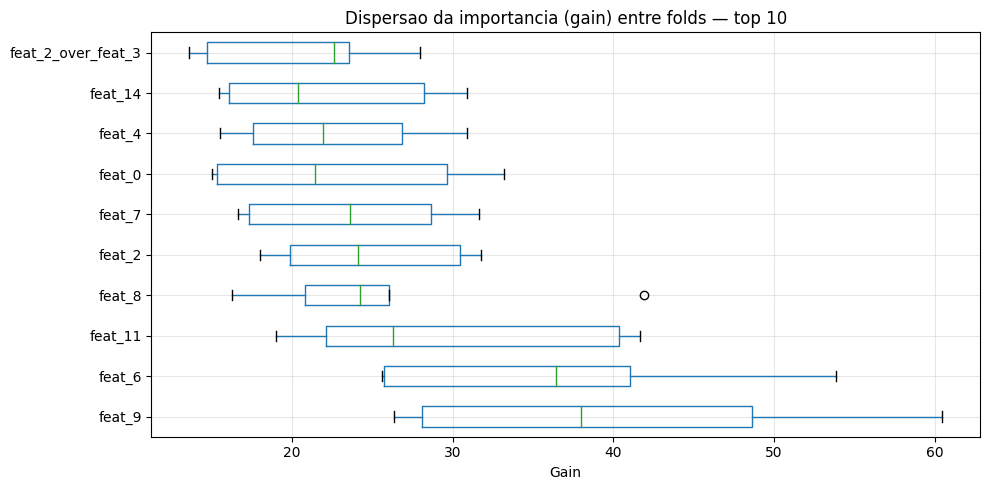


  Resumo das top-10 features por gain medio:
                    mean_gain  std_gain  folds_com_ganho  cv_gain
feat_9                40.3014   14.3654                5   0.3564
feat_6                36.5532   11.7751                5   0.3221
feat_11               29.8927   10.4882                5   0.3509
feat_8                25.8602    9.7209                5   0.3759
feat_2                24.8577    6.1502                5   0.2474
feat_7                23.5888    6.6561                5   0.2822
feat_0                22.9381    8.2474                5   0.3595
feat_4                22.5713    6.3670                5   0.2821
feat_14               22.2285    7.0519                5   0.3172
feat_2_over_feat_3    20.5090    6.1424                5   0.2995

  Interpretacao:
    - mean_gain alto: feature importante em media entre os folds
    - std_gain alto: importancia oscila consideravelmente entre folds
    - cv_gain alto: importancia instavel em termos relativos
    - folds_co

In [21]:
# ---------------------------------------------------------------------
# Bloco 17 — (Extensao) Estabilidade de importancias entre folds
# ---------------------------------------------------------------------
#
# Este bloco visualiza a dispersao da importancia (gain) das top-10
# features entre os folds da validacao cruzada realizada no Bloco 7.
#
# Se uma feature tem importancia alta em um fold e baixa em outro
# (caixa larga no boxplot), sua contribuicao e instavel. Isso pode
# indicar:
#   - Redundancia com outra feature (o modelo alterna entre elas)
#   - Sensibilidade a composicao da amostra de treino
#   - Amostra insuficiente para estimar o efeito de forma confiavel
#
# Features com importancia estavel (caixa estreita) sao mais
# confiaveis para interpretacao e para uso em producao.

print("=" * 70)
print("(Extensao) Estabilidade de importancias entre folds")
print("=" * 70)

if "imp_df" in globals() and imp_df is not None and not imp_df.empty:
    # Calcula estatisticas de importancia por feature entre os folds
    imp_summary = pd.DataFrame({
        "mean_gain": imp_df.mean(axis=0),       # importancia media
        "std_gain": imp_df.std(axis=0),          # dispersao absoluta
        "folds_com_ganho": (imp_df > 0).sum(axis=0),  # em quantos folds a feature foi usada
    })

    # Coeficiente de variacao do gain: dispersao relativa a media.
    # Valores altos indicam instabilidade proporcional.
    imp_summary["cv_gain"] = imp_summary["std_gain"] / (imp_summary["mean_gain"] + 1e-9)
    imp_summary = imp_summary.sort_values("mean_gain", ascending=False)

    top_feats = imp_summary.head(10).index.tolist()

    # Boxplot mostrando a distribuicao do gain de cada feature entre
    # os folds. A "caixa" cobre do percentil 25 ao 75.
    fig, ax = plt.subplots(figsize=(10, 5))
    imp_df[top_feats].boxplot(ax=ax, vert=False)
    ax.set_title("Dispersao da importancia (gain) entre folds — top 10")
    ax.set_xlabel("Gain")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()

    print(f"\n  Resumo das top-10 features por gain medio:")
    print(
        imp_summary.loc[top_feats].to_string(
            float_format=lambda x: f"{x:.4f}"
        )
    )

    print(f"\n  Interpretacao:")
    print(f"    - mean_gain alto: feature importante em media entre os folds")
    print(f"    - std_gain alto: importancia oscila consideravelmente entre folds")
    print(f"    - cv_gain alto: importancia instavel em termos relativos")
    print(f"    - folds_com_ganho baixo: feature nao e usada em varios folds")
else:
    print("  Sem dados de importancia por fold disponiveis.")